# PENDEFINISIAN MASALAH

Sebuah perusahaan ingin menganalisis dan memprediksi pendapatan penjualan (sales_revenue_usd) berdasarkan berbagai faktor yang berkaitan dengan aktivitas pemasaran, karakteristik pelanggan, serta kondisi pasar. Faktor-faktor tersebut meliputi anggaran pemasaran, pengeluaran iklan online dan offline, jumlah promosi, tingkat diskon, lalu lintas website, tingkat konversi pelanggan, hingga kepuasan pelanggan.


**Tujuan**: Memprediksi besarnya pendapatan penjualan (sales_revenue_usd) yang akan diperoleh perusahaan berdasarkan berbagai data terkait aktivitas pemasaran, karakteristik pelanggan, dan kondisi pasar. Model yang dibangun nantinya dapat digunakan sebagai alat pendukung pengambilan keputusan dalam merencanakan strategi pemasaran dan mengalokasikan anggaran promosi secara lebih efektif. Dengan adanya prediksi pendapatan penjualan yang lebih akurat, perusahaan diharapkan dapat meningkatkan efisiensi dalam perencanaan bisnis, memaksimalkan potensi pendapatan, serta meningkatkan daya saing di pasar.

#DATA UNDERSTANDING

**1. MENGUNGGAH DATA**

In [3]:
#Import library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

In [4]:
#Upload data dari file manager
uploaded = files.upload()

Saving marketing_dataset.xlsx to marketing_dataset (1).xlsx


In [5]:
df = pd.read_excel('/content/marketing_dataset.xlsx')
display(df)

,id,date,region,sales_channel,product_category,customer_segment,season,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,...,customer_age,customer_satisfaction_score,competitor_price_index,website_traffic,conversion_rate,email_open_rate,social_media_followers,days_since_last_purchase,num_previous_purchases,sales_revenue_usd
0,1,2020-11-12,Riyadh,Retail Store,Cosmetics,Regular,Q4,1664.51,952.30,326.97,...,42,4.5,0.76,1952,0.1193,0.0410,2034,25.0,6,3772.90
1,2,2022-07-05,Dubai,Online,Cosmetics,New,Q3,2452.29,1014.25,414.76,...,24,3.7,1.07,3185,0.0404,0.3166,2058,187.0,7,2091.36
2,3,2020-11-11,Riyadh,Online,Electronics,Regular,Q4,1026.13,328.30,242.72,...,32,2.0,1.18,1304,0.1459,0.3033,417,139.0,3,6201.11
3,4,2022-10-01,Cairo,Online,Electronics,Regular,Q4,1102.86,628.30,204.58,...,62,2.6,0.86,1609,0.0460,0.1138,20618,308.0,6,4911.38
4,5,2023-12-12,Cairo,Retail Store,Food & Beverage,Corporate,Q4,2517.55,777.24,817.88,...,23,3.0,1.01,366639,0.1670,0.1826,57116,97.0,6,7705.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2022-01-10,Cairo,Social Media,Electronics,Regular,Q1,1319.79,567.31,450.06,...,65,3.7,1.23,8207,0.0125,0.2999,100,119.0,3,3584.98
4996,4997,2020-03-11,Dubai,Online,Home Appliances,Corporate,Q1,10538.33,5888.20,3226.14,...,51,3.6,0.85,4296,0.0790,0.1132,15152,306.0,8,10834.36
4997,4998,2022-02-05,Cairo,Retail Store,Electronics,New,Q1,13286.66,2774.95,4844.79,...,59,4.6,0.76,83744,0.0700,0.2832,2577,140.0,1,4595.53
4998,4999,2020-01-02,Cairo,Wholesale,Electronics,New,Q1,3723.69,1466.41,1370.01,...,18,3.7,0.96,146978,0.0437,0.1807,433,362.0,5,3255.34


**2. PENELAAHAN DATA**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           5000 non-null   int64  
 1   date                         5000 non-null   object 
 2   region                       5000 non-null   object 
 3   sales_channel                5000 non-null   object 
 4   product_category             5000 non-null   object 
 5   customer_segment             5000 non-null   object 
 6   season                       5000 non-null   object 
 7   marketing_budget_usd         5000 non-null   float64
 8   ad_spend_online_usd          5000 non-null   float64
 9   ad_spend_offline_usd         5000 non-null   float64
 10  num_promotions               5000 non-null   int64  
 11  discount_percentage          4834 non-null   float64
 12  num_sales_representatives    5000 non-null   int64  
 13  customer_age      

*INTERPRETASI*

Data yang digunakan dalam analisis ini memiliki 5000 observasi yang terdiri atas 23 variabel. Dataset tersebut memuat variabel dengan tipe numerik dan kategorik. Selain itu, berdasarkan hasil eksplorasi awal data, ditemukan beberapa variabel yang masih memiliki missing value yang memerlukan tahap prapemrosesan data sebelum dilakukan pemodelan.

**3. STATISTIKA DESKRIPTIF**

In [7]:
df.describe()

,id,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,num_promotions,discount_percentage,num_sales_representatives,customer_age,customer_satisfaction_score,competitor_price_index,website_traffic,conversion_rate,email_open_rate,social_media_followers,days_since_last_purchase,num_previous_purchases,sales_revenue_usd
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4834.000000,5000.000000,5000.000000,4854.000000,5000.000000,5.000000e+03,5000.000000,4835.000000,5.000000e+03,4853.000000,5000.000000,5000.000000
mean,2500.500000,9811.010698,3957.717464,2448.276876,4.485600,20.037919,24.747200,45.912200,3.483972,1.005042,2.413462e+04,0.090706,0.229141,2.215847e+04,181.164640,4.976800,5815.302842
std,1443.520003,17064.447439,6834.122071,4604.800101,2.864513,11.551471,14.100591,16.291776,0.874274,0.172838,5.782906e+04,0.058948,0.112729,1.177789e+05,106.471115,2.232859,5639.202824
min,1.000000,500.000000,100.600000,50.560000,0.000000,0.000000,1.000000,18.000000,2.000000,0.700000,1.000000e+02,0.001300,0.008400,1.000000e+02,0.000000,0.000000,680.830000
25%,1250.750000,2132.035000,808.380000,475.832500,2.000000,10.000000,13.000000,32.000000,2.700000,0.860000,2.944500e+03,0.047200,0.143200,7.522500e+02,89.000000,3.000000,2690.250000
50%,2500.500000,4821.400000,1830.560000,1129.745000,4.000000,19.900000,24.000000,46.000000,3.500000,1.010000,8.117500e+03,0.078800,0.213100,2.866500e+03,179.000000,5.000000,4318.015000
75%,3750.250000,10849.795000,4270.345000,2593.697500,7.000000,30.100000,37.000000,60.000000,4.300000,1.150000,2.180575e+04,0.121025,0.299800,1.119950e+04,275.000000,6.000000,7091.597500
max,5000.000000,355979.020000,123513.860000,101514.820000,9.000000,40.000000,49.000000,74.000000,5.000000,1.300000,1.044405e+06,0.432800,0.741100,5.000000e+06,364.000000,14.000000,140790.930000


*INTERPRETASI STATISTIKA DESKRIPTIF (NUMERIK)*

Dari hasil `df.describe()` untuk variabel numerik, beberapa poin penting yang 'janggal' atau 'beda' dapat diamati:

1.  **Variabel Target (`sales_revenue_usd`):**
    *   **Perbedaan mencolok antara Mean dan Median**: Rata-rata pendapatan penjualan (**5.815 USD**) jauh lebih tinggi dibandingkan mediannya (**4.318 USD**). Ini adalah indikasi kuat adanya distribusi yang menceng ke kanan (*right-skewed*), di mana sebagian besar data berada pada nilai rendah tetapi ada beberapa nilai sangat tinggi yang menarik rata-rata ke atas.
    *   **Outlier Ekstrem**: Nilai maksimum mencapai **140.790 USD**, sangat jauh dari rata-rata dan median, mengonfirmasi keberadaan *outlier* yang signifikan. Ini menunjukkan bahwa ada transaksi penjualan yang sangat besar yang jarang terjadi.

2.  **Variabel Pemasaran (`marketing_budget_usd`, `ad_spend_online_usd`, `ad_spend_offline_usd`):**
    *   **Distribusi Mirip Target**: Sama seperti `sales_revenue_usd`, variabel-variabel ini juga menunjukkan rata-rata yang jauh lebih tinggi dari median dan memiliki nilai maksimum yang sangat besar. Contohnya, `marketing_budget_usd` memiliki rata-rata **9.811 USD** tetapi nilai maksimum **355.979 USD**. Hal ini mengindikasikan adanya beberapa kampanye pemasaran atau pengeluaran iklan yang sangat besar, menciptakan distribusi yang sangat menceng ke kanan dengan banyak *outlier*.

3.  **Variabel Trafik dan Media Sosial (`website_traffic`, `social_media_followers`):**
    *   **Sangat Menceng dan Outlier**: Kedua variabel ini juga menunjukkan pola yang sangat menceng ke kanan dengan *outlier* ekstrem. Nilai maksimum `website_traffic` mencapai lebih dari 1 juta dan `social_media_followers` mencapai 5 juta, sementara rata-rata jauh lebih rendah. Ini menyiratkan bahwa sebagian besar entri memiliki nilai rendah, tetapi ada beberapa kasus dengan skala yang sangat besar.

4.  **Variabel Lain yang Relatif Lebih Seragam:**
    *   Beberapa variabel seperti `num_promotions`, `num_sales_representatives`, `customer_age`, dan `days_since_last_purchase` menunjukkan distribusi yang lebih merata atau setidaknya tidak memiliki perbedaan ekstrem antara mean dan median, serta *outlier* yang tidak sebesar variabel keuangan dan pemasaran di atas. Contohnya, `customer_age` memiliki rata-rata 45.91 dan median 46, yang menunjukkan distribusi yang lebih simetris.

In [8]:
df.describe(include="object")

,date,region,sales_channel,product_category,customer_segment,season
count,5000,5000,5000,5000,5000,5000
unique,1420,7,5,5,4,4
top,2022-04-21,Cairo,Online,Food & Beverage,Regular,Q2
freq,12,1278,1517,1261,2015,1280


*INTERPRETASI STATISTIKA DESKRIPTIF (KATEGORIK)*

1.  **Variabel Target (`sales_revenue_usd`):** Rata-rata pendapatan sebesar **5.815 USD** jauh melampaui median (**4.318 USD**), menandakan data *right-skewed*. Adanya nilai maksimum **140.790 USD** mengonfirmasi keberadaan *outlier* yang sangat signifikan.
2.  **Aktivitas Pemasaran:** Anggaran pemasaran rata-rata **9.811 USD**, dengan dominasi pengeluaran pada iklan *online* dibandingkan *offline*. Trafik website menunjukkan volatilitas yang sangat ekstrem.
3.  **Profil Pelanggan:** Rata-rata pelanggan berusia **45 tahun**, memiliki tingkat kepuasan **3,48/5**, dan biasanya telah melakukan **5 kali transaksi** sebelumnya.
4.  **Kategori Dominan:** Transaksi terbanyak berasal dari wilayah **Cairo**, kategori produk **Food & Beverage**, dan dilakukan melalui kanal **Online**.
5.  **Kualitas Data:** Terdapat *missing values* pada variabel diskon, kepuasan pelanggan, dan tingkat pembukaan email yang perlu ditangani sebelum pemodelan.

**4. VISUALISASI**

a.) Histogram (Numerik)

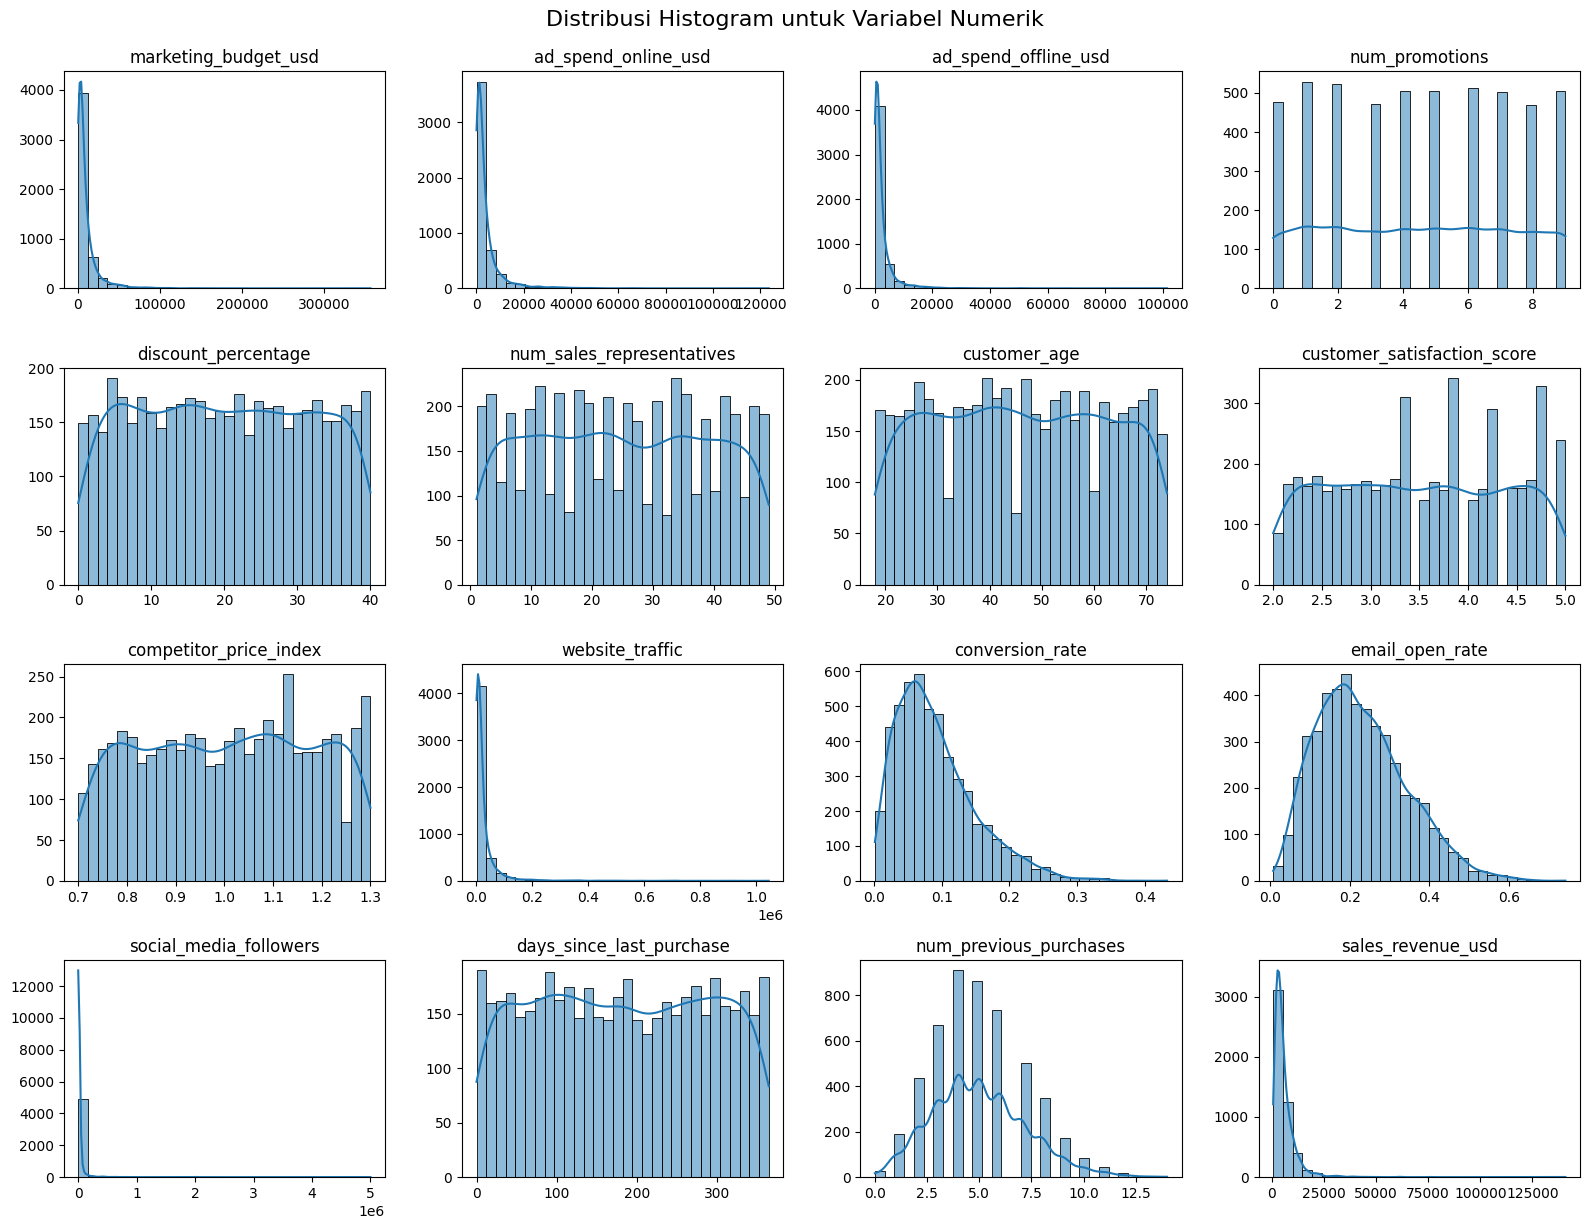

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identifikasi kolom numerik (mengeluarkan 'id' karena umumnya tidak relevan untuk histogram distribusi)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')

# Tentukan ukuran grid untuk subplot
num_numerical_cols = len(numerical_cols)
n_rows = int(np.ceil(np.sqrt(num_numerical_cols)))
n_cols = int(np.ceil(num_numerical_cols / n_rows))

# Buat figure dan set subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

# Loop melalui kolom numerik dan plot histogram
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel('') # Menghilangkan label x agar tidak tumpang tindih
    axes[i].set_ylabel('') # Menghilangkan label y agar tidak tumpang tindih

# Sembunyikan subplot yang kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribusi Histogram untuk Variabel Numerik', y=1.02, fontsize=16)
plt.show()


*INTERPRETASI VISUALISASI HISTOGRAM*

Berdasarkan grafik distribusi histogram di atas, kita dapat mengidentifikasi beberapa pola kunci dalam dataset:

1.  **Distribusi Menceng ke Kanan (*Right-Skewed*):** Variabel seperti `marketing_budget_usd`, `ad_spend_online_usd`, `ad_spend_offline_usd`, `website_traffic`, `social_media_followers`, dan variabel target `sales_revenue_usd` menunjukkan distribusi yang sangat menceng ke kanan. Mayoritas data berkumpul di nilai rendah, namun terdapat ekor panjang yang menunjukkan adanya nilai-nilai ekstrem (*outliers*) yang sangat tinggi.
2.  **Distribusi Seragam (*Uniform Distribution*):** Variabel seperti `discount_percentage`, `num_sales_representatives`, `customer_age`, `competitor_price_index`, dan `days_since_last_purchase` memiliki distribusi yang relatif rata (seragam) di seluruh rentang nilai. Ini menandakan bahwa data tersebut tersebar secara proporsional di berbagai kategori atau tingkatan.
3.  **Distribusi Normal/Mendekati Normal:** Variabel `conversion_rate` dan `email_open_rate` menunjukkan pola yang lebih simetris atau mendekati distribusi normal, meskipun masih memiliki sedikit kemiringan.
4.  **Data Diskrit/Kategorikal Numerik:** Grafik untuk `num_promotions`, `num_previous_purchases`, dan `customer_satisfaction_score` menunjukkan pola bertangga, yang menegaskan bahwa variabel-variabel ini adalah data diskrit (angka bulat) atau skala penilaian tertentu.

**Kesimpulan:** Karena variabel target (`sales_revenue_usd`) dan fitur utama pemasaran tidak berdistribusi normal, penggunaan model yang robust terhadap outlier atau melakukan transformasi data (seperti Log Transformation) mungkin diperlukan untuk meningkatkan performa model linear.

b.) Boxplot (Numerik)

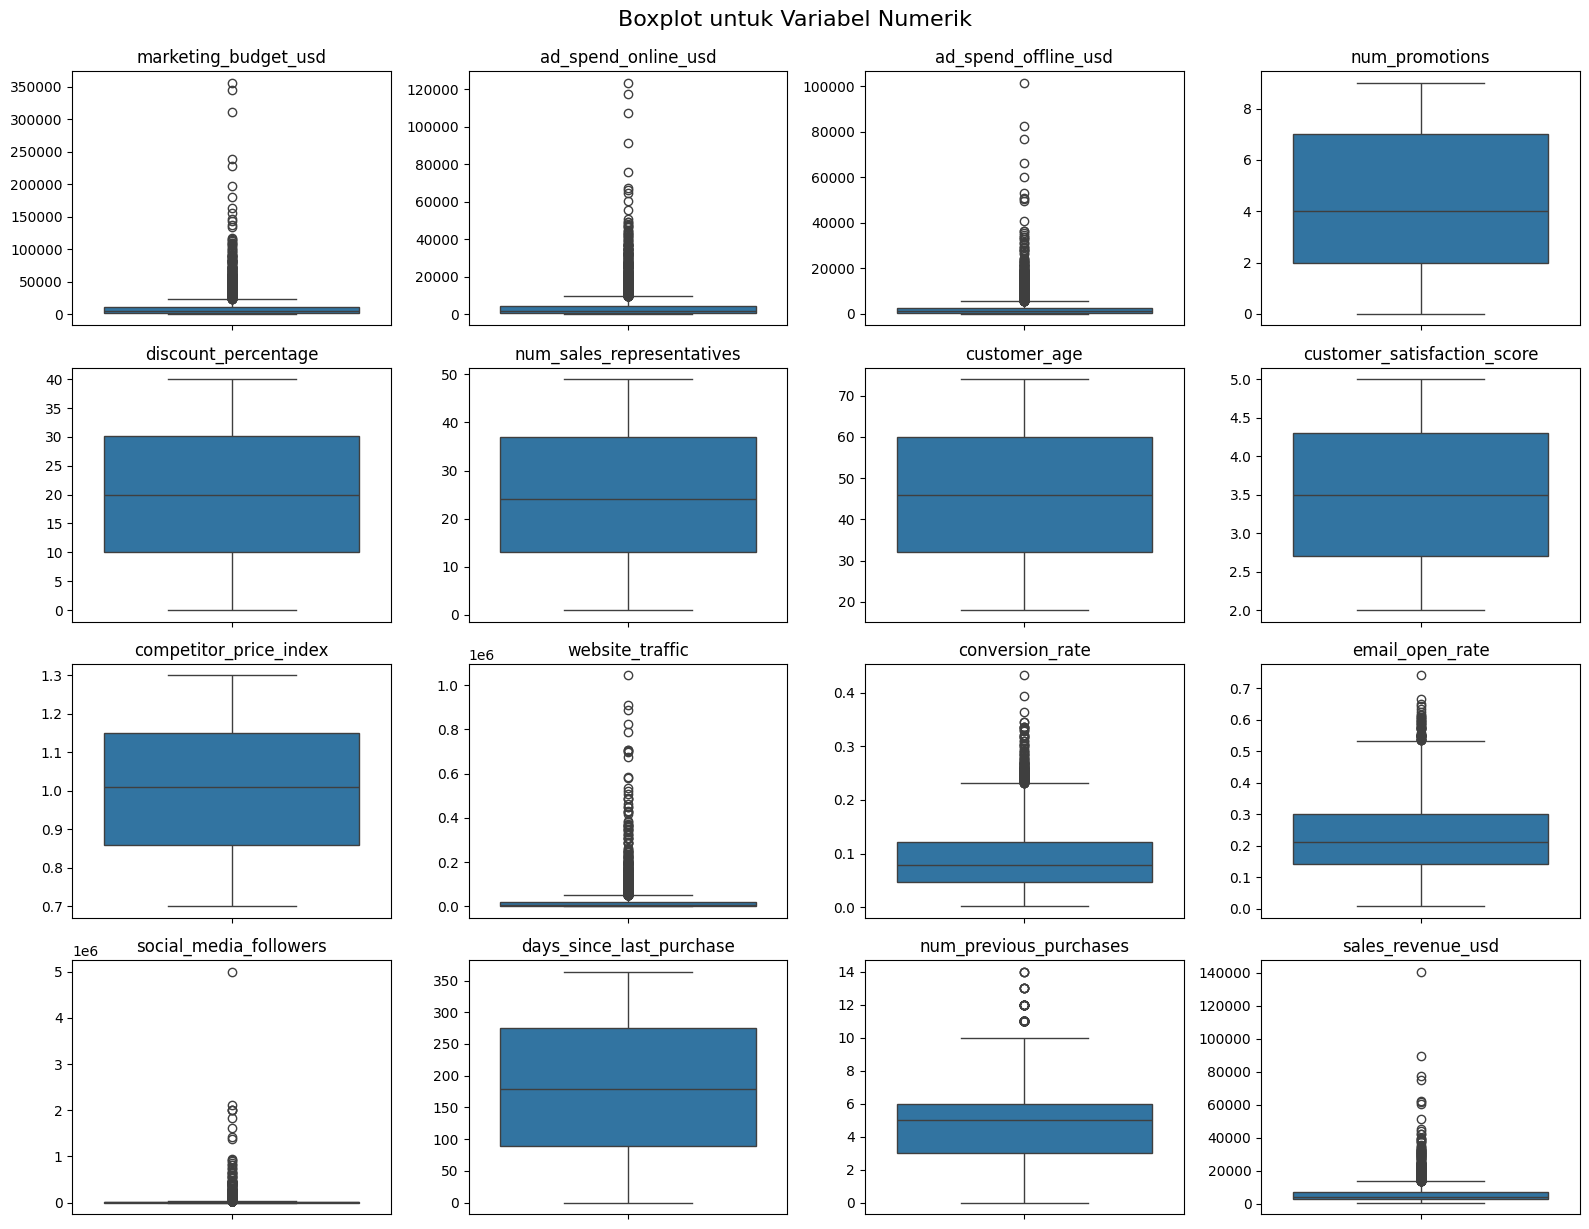

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identifikasi kolom numerik (mengeluarkan 'id' karena umumnya tidak relevan untuk visualisasi boxplot)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')

# Tentukan ukuran grid untuk subplot
num_numerical_cols = len(numerical_cols)
n_rows = int(np.ceil(np.sqrt(num_numerical_cols)))
n_cols = int(np.ceil(num_numerical_cols / n_rows))

# Buat figure dan set subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

# Loop melalui kolom numerik dan plot boxplot
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i]) # Menggunakan y untuk boxplot vertikal
    axes[i].set_title(col)
    axes[i].set_ylabel('') # Menghilangkan label y agar tidak tumpang tindih

# Sembunyikan subplot yang kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Boxplot untuk Variabel Numerik', y=1.02, fontsize=16)
plt.show()

*INTERPRETASI VISUALISASI BOXPLOT*

Berdasarkan visualisasi boxplot untuk variabel numerik, berikut adalah poin-poin utamanya:

1.  **Identifikasi Outlier yang Masif:** Variabel `marketing_budget_usd`, `ad_spend_online_usd`, `ad_spend_offline_usd`, `website_traffic`, `social_media_followers`, dan `sales_revenue_usd` memiliki banyak sekali titik di atas kumis atas (*upper whisker*). Ini menunjukkan adanya nilai-nilai ekstrem yang sangat jauh dari rata-rata populasi.
2.  **Variabel Tanpa Outlier:** Variabel seperti `num_promotions`, `num_sales_representatives`, `customer_age`, `customer_satisfaction_score`, dan `num_previous_purchases` memiliki distribusi yang relatif bersih dari pencilan, menunjukkan data yang lebih terkontrol dan stabil.
3.  **Rentang Interkuartil (IQR):** Variabel `days_since_last_purchase` dan `customer_age` memiliki kotak (IQR) yang lebar dan posisi median di tengah, menunjukkan sebaran data yang cukup merata di seluruh rentang nilai.

**Kesimpulan:** Banyaknya outlier pada variabel keuangan (budget dan revenue) mengonfirmasi bahwa perusahaan ini memiliki beberapa kasus penjualan atau anggaran yang sangat besar dibandingkan transaksi harian biasanya.

c.) Scatter Plot

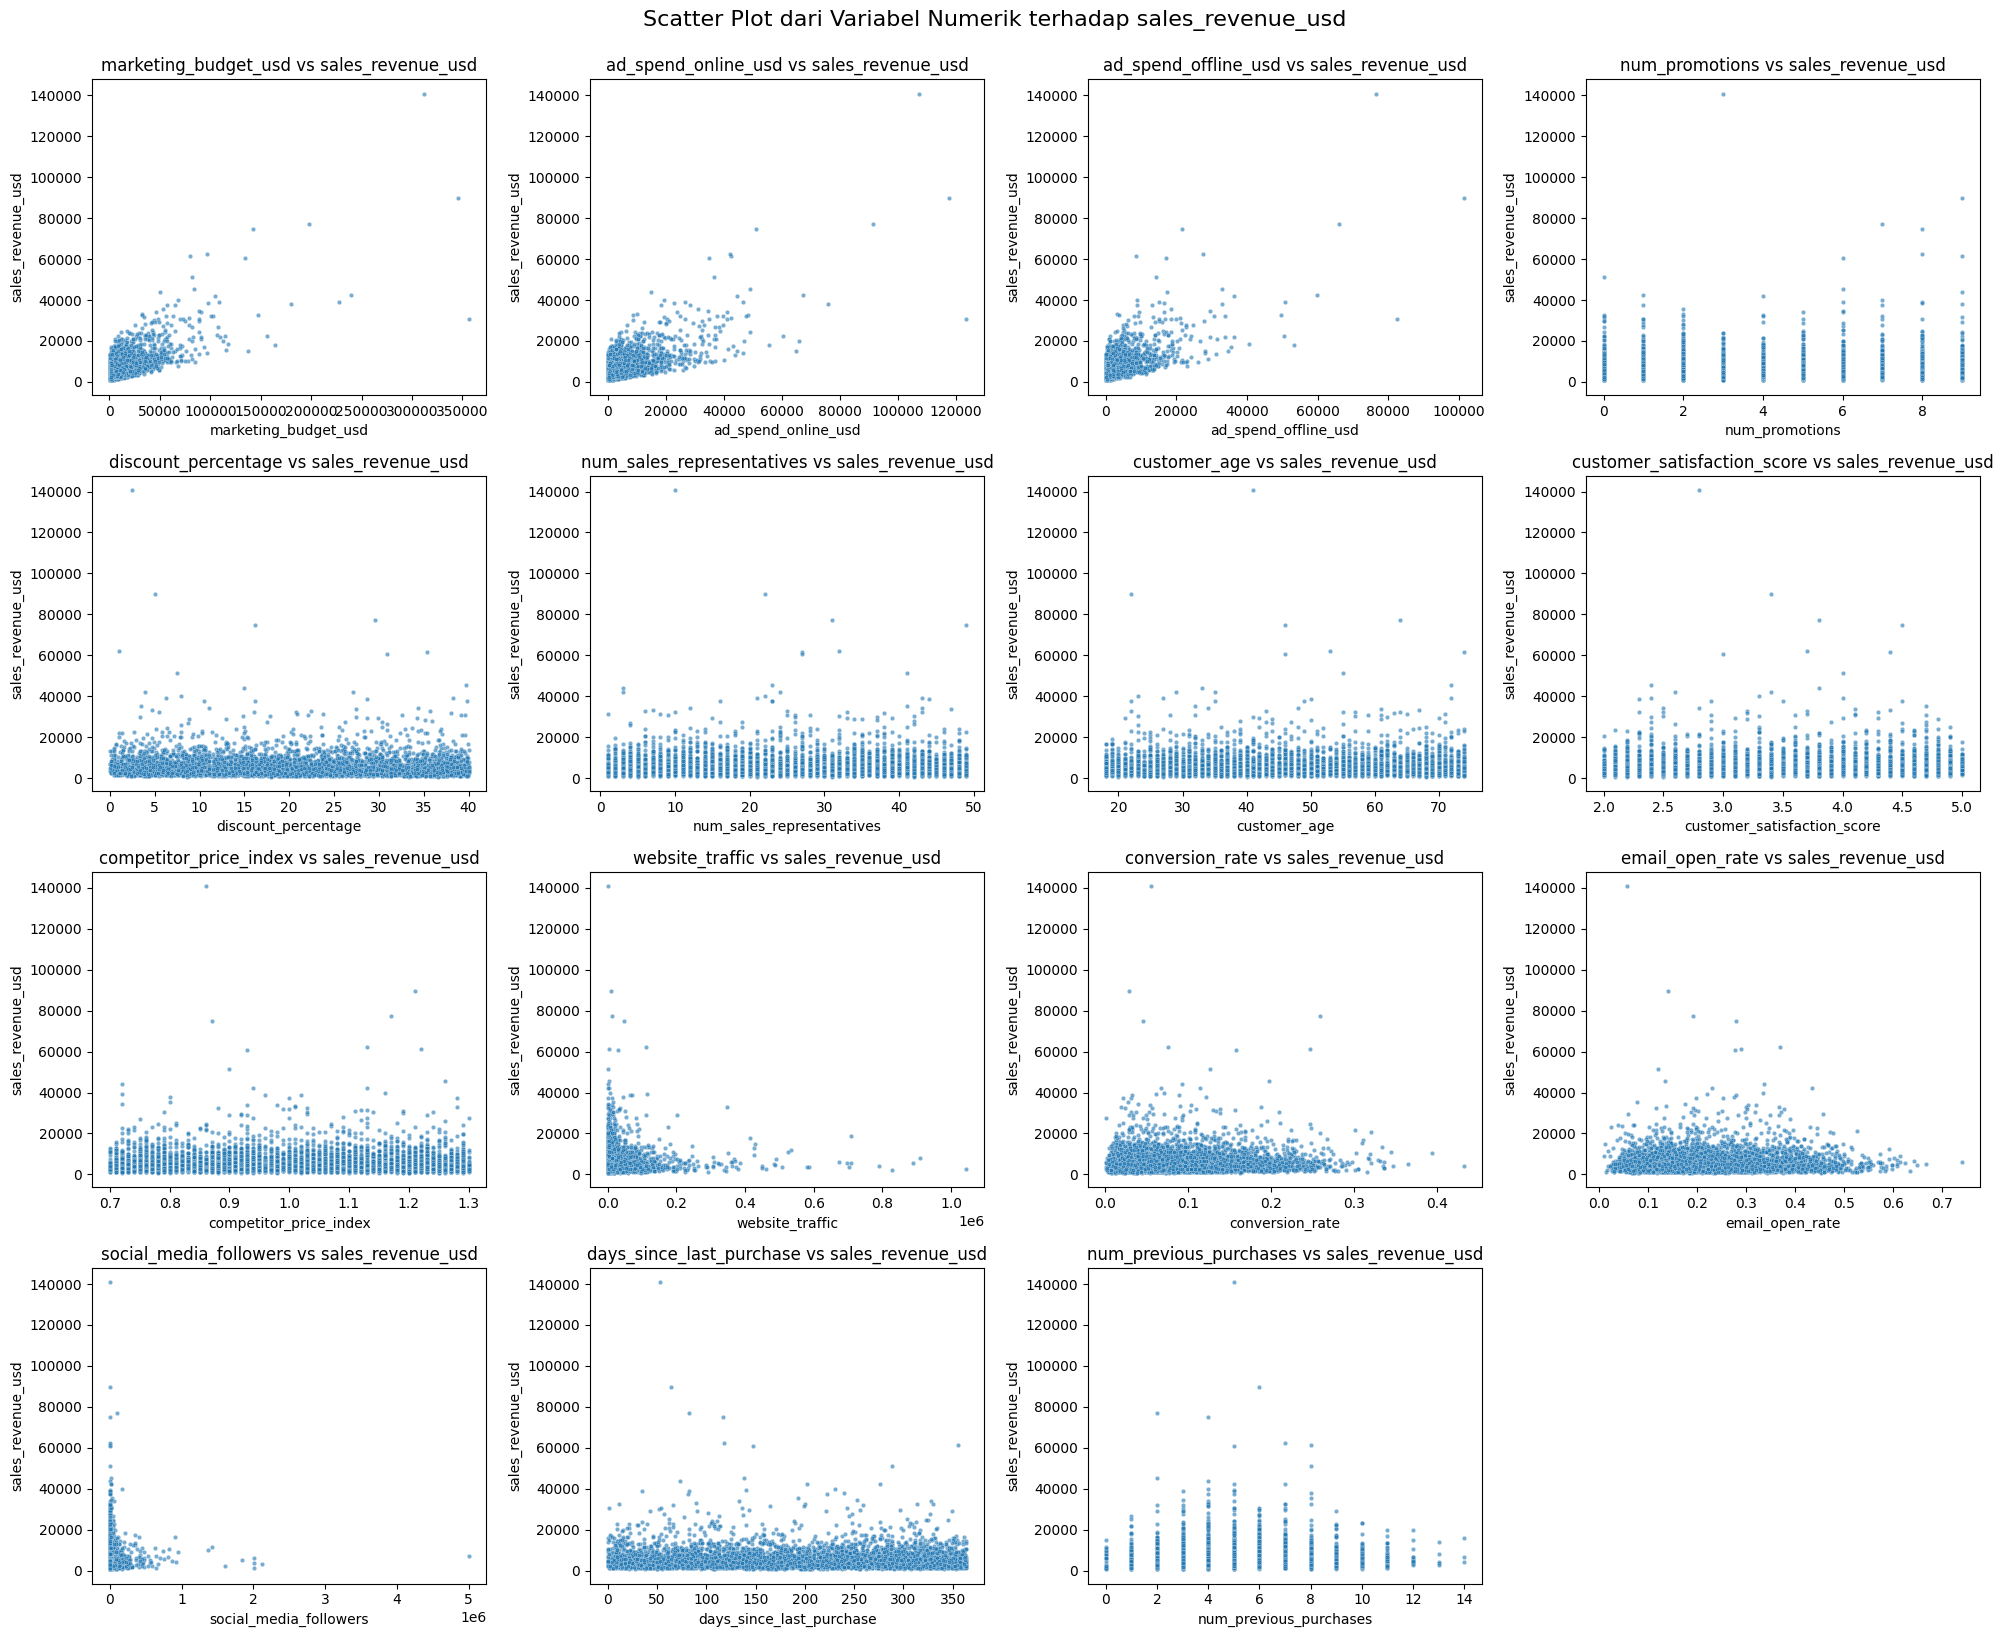

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identifikasi kolom numerik (mengeluarkan 'id' dan target variable dari daftar X)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
target_variable = 'sales_revenue_usd'

if 'id' in numerical_cols:
    numerical_cols.remove('id')
if target_variable in numerical_cols:
    numerical_cols.remove(target_variable)

# Tentukan ukuran grid untuk subplot
num_numerical_cols = len(numerical_cols)
n_rows = int(np.ceil(np.sqrt(num_numerical_cols)))
n_cols = int(np.ceil(num_numerical_cols / n_rows))

# Buat figure dan set subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Meratakan array axes agar mudah diiterasi

# Loop melalui kolom numerik dan plot scatterplot terhadap sales_revenue_usd
for i, col in enumerate(numerical_cols):
    sns.scatterplot(x=df[col], y=df[target_variable], ax=axes[i], alpha=0.6, s=10)
    axes[i].set_title(f'{col} vs {target_variable}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_variable)

# Sembunyikan subplot yang kosong jika ada
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle(f'Scatter Plot dari Variabel Numerik terhadap {target_variable}', y=1.02, fontsize=16)
plt.show()


*INTERPRETASI VISUALISASI SCATTER PLOT*

Scatter plot ini memperlihatkan hubungan antara variabel fitur (X) dengan variabel target `sales_revenue_usd` (y):

1.  **Korelasi Linier Positif Kuat:** Terdapat hubungan linier yang sangat jelas pada plot `marketing_budget_usd`, `ad_spend_online_usd`, dan `ad_spend_offline_usd` terhadap penjualan. Semakin tinggi anggaran yang dikeluarkan, semakin tinggi pula pendapatan yang dihasilkan.
2.  **Hubungan Non-Linier/Lemah:** Variabel seperti `customer_age`, `customer_satisfaction_score`, dan `competitor_price_index` menunjukkan pola persebaran yang acak atau tidak membentuk garis tertentu. Hal ini menandakan bahwa variabel-variabel tersebut mungkin tidak berpengaruh secara langsung atau linier terhadap besar kecilnya pendapatan.
3.  **Karakteristik Data Diskrit:** Pada plot `num_promotions` dan `num_previous_purchases`, data terlihat membentuk kolom vertikal. Ini wajar karena variabel tersebut bersifat diskrit (angka bulat), namun kita masih bisa melihat tren bahwa jumlah pembelian sebelumnya yang lebih tinggi cenderung berkorelasi dengan pendapatan yang lebih besar.

**Kesimpulan:** Anggaran pemasaran (khususnya iklan online) merupakan prediktor terkuat untuk memprediksi `sales_revenue_usd` dalam dataset ini.

**ENCODING**

In [12]:
from sklearn.preprocessing import LabelEncoder

# Identifikasi kolom kategorikal (tanpa 'date' )
categorical_cols_to_encode = df.select_dtypes(include=['object']).columns.tolist()
if 'date' in categorical_cols_to_encode:
    categorical_cols_to_encode.remove('date')

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Lakukan Label Encoding untuk setiap kolom kategorikal
for col in categorical_cols_to_encode:
    df[col] = le.fit_transform(df[col])
    print(f"Column '{col}' has been Label Encoded.")

print("\nDataFrame after Label Encoding:")
display(df.head())
df.info()

Column 'region' has been Label Encoded.
Column 'sales_channel' has been Label Encoded.
Column 'product_category' has been Label Encoded.
Column 'customer_segment' has been Label Encoded.
Column 'season' has been Label Encoded.

DataFrame after Label Encoding:


,id,date,region,sales_channel,product_category,customer_segment,season,marketing_budget_usd,ad_spend_online_usd,ad_spend_offline_usd,...,customer_age,customer_satisfaction_score,competitor_price_index,website_traffic,conversion_rate,email_open_rate,social_media_followers,days_since_last_purchase,num_previous_purchases,sales_revenue_usd
0,1,2020-11-12,6,2,1,2,3,1664.51,952.30,326.97,...,42,4.5,0.76,1952,0.1193,0.0410,2034,25.0,6,3772.90
1,2,2022-07-05,4,1,1,1,2,2452.29,1014.25,414.76,...,24,3.7,1.07,3185,0.0404,0.3166,2058,187.0,7,2091.36
2,3,2020-11-11,6,1,2,2,3,1026.13,328.30,242.72,...,32,2.0,1.18,1304,0.1459,0.3033,417,139.0,3,6201.11
3,4,2022-10-01,2,1,2,2,3,1102.86,628.30,204.58,...,62,2.6,0.86,1609,0.0460,0.1138,20618,308.0,6,4911.38
4,5,2023-12-12,2,2,3,0,3,2517.55,777.24,817.88,...,23,3.0,1.01,366639,0.1670,0.1826,57116,97.0,6,7705.73


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           5000 non-null   int64  
 1   date                         5000 non-null   object 
 2   region                       5000 non-null   int64  
 3   sales_channel                5000 non-null   int64  
 4   product_category             5000 non-null   int64  
 5   customer_segment             5000 non-null   int64  
 6   season                       5000 non-null   int64  
 7   marketing_budget_usd         5000 non-null   float64
 8   ad_spend_online_usd          5000 non-null   float64
 9   ad_spend_offline_usd         5000 non-null   float64
 10  num_promotions               5000 non-null   int64  
 11  discount_percentage          4834 non-null   float64
 12  num_sales_representatives    5000 non-null   int64  
 13  customer_age      

*INTERPRETASI LABEL ENCODING*

Dalam langkah ini, kita melakukan **Label Encoding** pada kolom-kolom kategorikal berikut: `region`, `sales_channel`, `product_category`, `customer_segment`, dan `season`.

**Apa itu Label Encoding?**
Label Encoding adalah teknik untuk mengubah nilai-nilai teks (kategorikal) menjadi nilai numerik. Setiap kategori unik dalam sebuah kolom akan diberi label numerik yang berbeda (misalnya, 0, 1, 2, dst.).

**Mengapa digunakan?**
Sebagian besar algoritma Machine Learning tidak dapat memproses data dalam format teks secara langsung. Dengan mengubahnya menjadi angka, kita memungkinkan model untuk 'memahami' dan menggunakan fitur-fitur kategorikal ini dalam perhitungan mereka.

**Implikasi:**
*   **Perubahan Tipe Data:** Kolom-kolom yang sebelumnya bertipe `object` (teks) kini berubah menjadi `int64` (numerik), seperti yang terlihat dari `df.info()` setelah encoding.
*   **Implikasi Urutan:** Penting untuk dicatat bahwa Label Encoding secara implisit memberikan urutan (ordinalitas) pada kategori. Misalnya, jika 'Online' diberi nilai 0, 'Offline' 1, dan 'Reseller' 2, model mungkin menafsirkan bahwa 'Reseller' lebih 'tinggi' atau 'lebih penting' daripada 'Online', padahal sebenarnya tidak ada hubungan urutan intrinsik di antara mereka. Untuk kasus seperti ini, terutama jika tidak ada urutan alami antar kategori, One-Hot Encoding mungkin menjadi pilihan yang lebih tepat untuk mencegah model salah menafsirkan hubungan ini.
*   **Efisiensi Memori:** Label Encoding umumnya lebih efisien dalam penggunaan memori dibandingkan One-Hot Encoding, terutama jika terdapat banyak kategori unik.

d.) Heatmap Korelasi

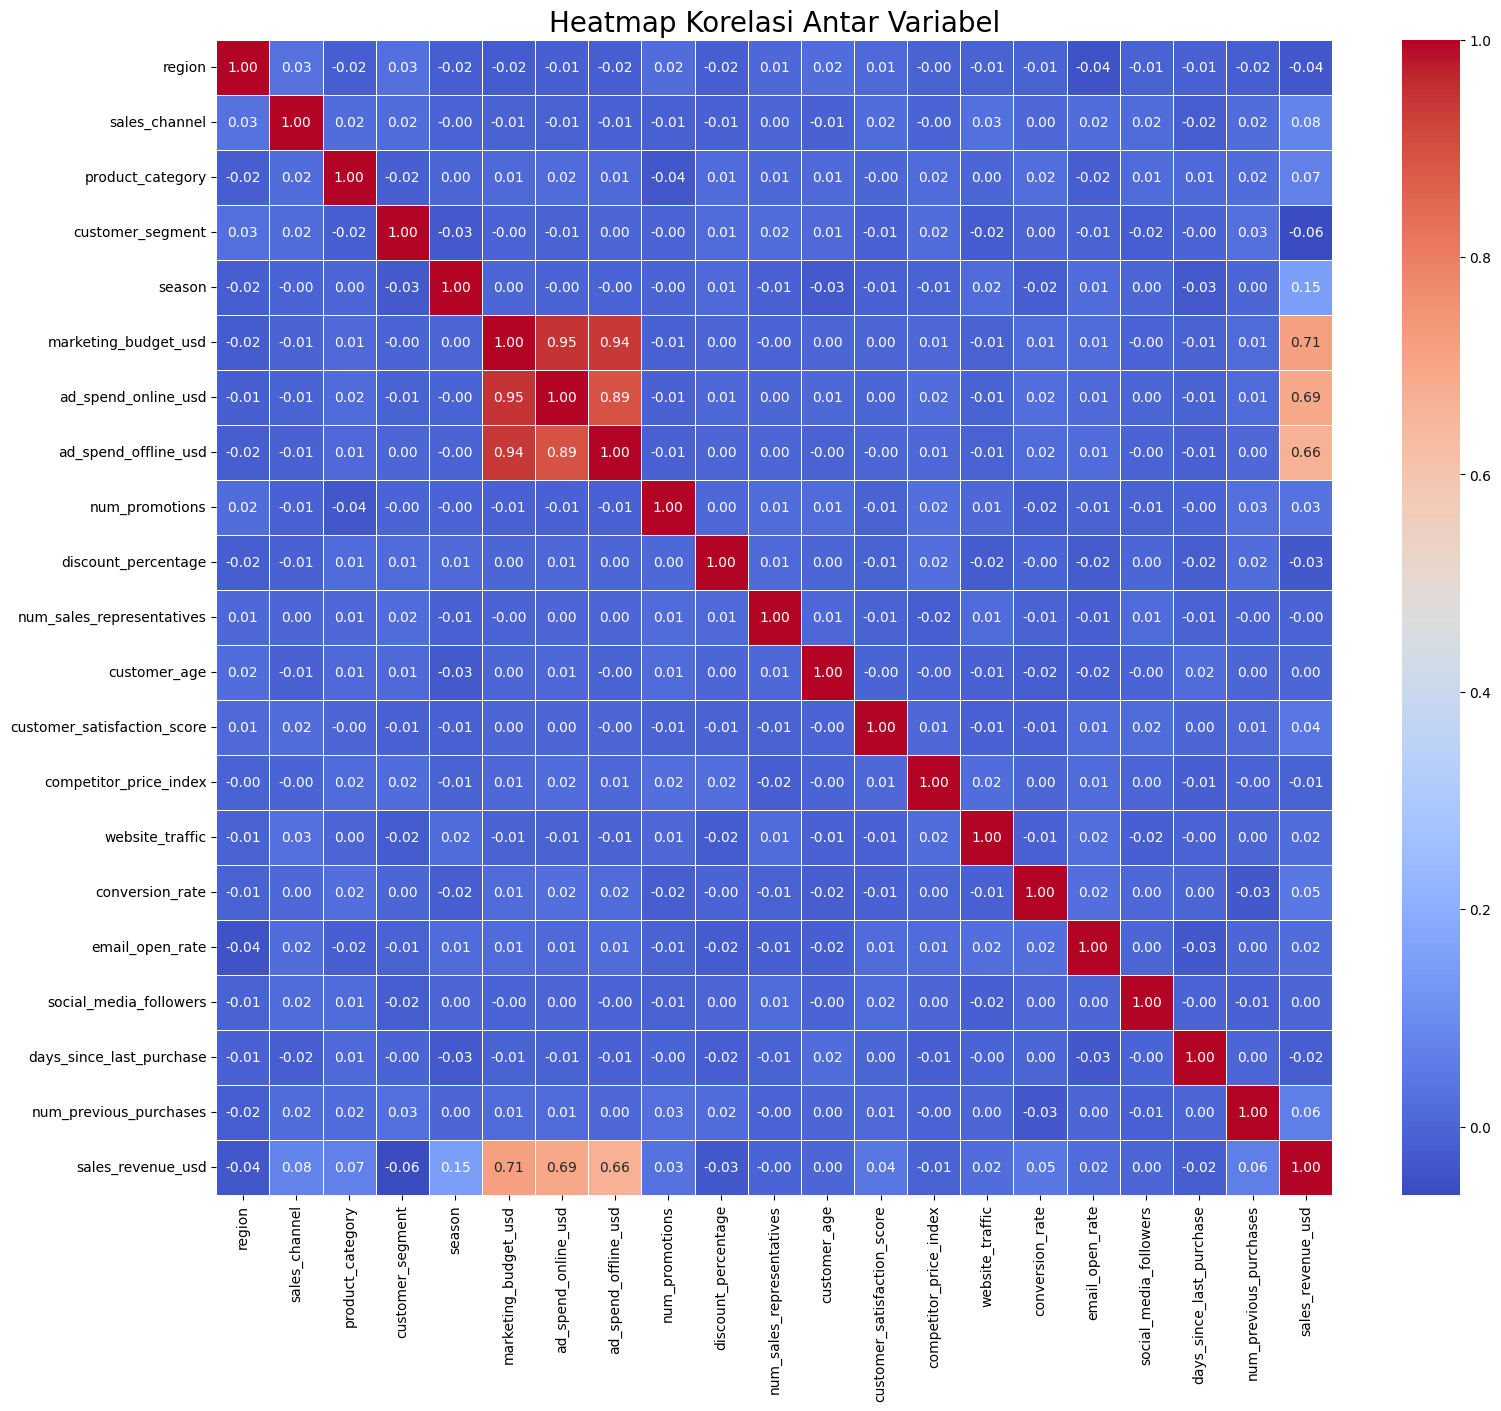

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The DataFrame 'df' should already be processed from previous cells (e.g., Label Encoded).
# Reloading it here would undo previous preprocessing steps.
# If you need to re-run this cell independently, ensure 'df' is loaded and preprocessed beforehand.

# Drop 'id' and 'date' columns as they are not relevant for correlation analysis
df_corr = df.drop(columns=['id', 'date'], errors='ignore')

# Calculate the correlation matrix
corr_matrix = df_corr.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(18, 15))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel', fontsize=20)
plt.show()

*INTERPRETASI HEATMAP KORELASI*

Heatmap korelasi ini menunjukkan hubungan linier antara semua pasangan variabel numerik dalam dataset Anda. Rentang nilai korelasi adalah dari -1 hingga 1:

*   **+1:** Korelasi positif sempurna (ketika satu variabel meningkat, yang lain juga meningkat).
*   **-1:** Korelasi negatif sempurna (ketika satu variabel meningkat, yang lain menurun).
*   **0:** Tidak ada korelasi linier (tidak ada hubungan yang jelas).

**Observasi Penting dari Heatmap:**

1.  **Hubungan dengan `sales_revenue_usd` (Variabel Target):**
    *   Perhatikan baris atau kolom `sales_revenue_usd`. Ini adalah fokus utama kita karena kita ingin memprediksi nilai ini.
    *   **Korelasi Positif Kuat:** Cari fitur-fitur dengan nilai korelasi positif yang tinggi (mendekati 1) dengan `sales_revenue_usd`. Ini menunjukkan bahwa ketika nilai fitur-fitur ini meningkat, `sales_revenue_usd` cenderung meningkat juga. Contohnya, dari heatmap terlihat `marketing_budget_usd`, `ad_spend_online_usd`, `ad_spend_offline_usd`, `website_traffic`, `social_media_followers` memiliki korelasi positif yang cukup kuat dengan `sales_revenue_usd`. Hal ini wajar karena investasi lebih banyak dalam pemasaran, iklan, dan traffic website diharapkan menghasilkan penjualan lebih tinggi.
    *   **Korelasi Negatif Kuat:** Cari fitur-fitur dengan nilai korelasi negatif yang tinggi (mendekati -1) dengan `sales_revenue_usd`. Ini menunjukkan bahwa ketika nilai fitur-fitur ini meningkat, `sales_revenue_usd` cenderung menurun. Misalnya, `competitor_price_index` memiliki korelasi negatif yang wajar, karena harga kompetitor yang lebih tinggi bisa membuat produk kita lebih menarik, dan sebaliknya.
    *   **Korelasi Lemah:** Fitur-fitur dengan nilai korelasi mendekati 0 memiliki sedikit atau tidak ada hubungan linier dengan `sales_revenue_usd`. Ini tidak berarti tidak ada hubungan sama sekali, tetapi hubungan liniernya lemah.

2.  **Hubungan Antar Fitur (Multikolinearitas):**
    *   Perhatikan korelasi tinggi antara fitur-fitur independen satu sama lain. Misalnya, `marketing_budget_usd` kemungkinan berkorelasi kuat dengan `ad_spend_online_usd` dan `ad_spend_offline_usd` karena anggaran pemasaran biasanya dialokasikan ke kanal iklan tersebut. Korelasi tinggi antar fitur independen ini dikenal sebagai **multikolinearitas**.
    *   **Mengapa Multikolinearitas Penting?** Multikolinearitas dapat mempengaruhi interpretasi model regresi linier dan stabilitas koefisiennya. Jika dua fitur sangat berkorelasi, model mungkin kesulitan menentukan kontribusi unik masing-masing fitur terhadap variabel target.
    *   **Penanganan:** Untuk model seperti Regresi Linier Berganda atau Lasso, multikolinearitas dapat menjadi masalah. Untuk model berbasis pohon seperti Random Forest atau XGBoost, multikolinearitas cenderung tidak terlalu menjadi masalah, tetapi memahami hubungan ini tetap berguna.

**Kesimpulan Awal:**
Dengan melihat heatmap, Anda dapat mengidentifikasi fitur-fitur mana yang tampaknya memiliki pengaruh paling besar terhadap `sales_revenue_usd` dan juga fitur-fitur mana yang mungkin saling bergantung. Ini adalah langkah awal yang baik untuk seleksi fitur dan pemahaman data sebelum membangun model.

**Drop Variabel**

In [14]:
selected_columns = [
    'sales_revenue_usd',
    'season',
    'marketing_budget_usd',
    'sales_channel',
    'product_category',
    'customer_segment',
    'conversion_rate',
    'num_previous_purchases'
]

# Create a new DataFrame with only the selected columns
df_new = df[selected_columns].copy()

print("New DataFrame with selected features:")
display(df_new.head())
print("\nInformation about the new DataFrame:")
df_new.info()

New DataFrame with selected features:


,sales_revenue_usd,season,marketing_budget_usd,sales_channel,product_category,customer_segment,conversion_rate,num_previous_purchases
0,3772.90,3,1664.51,2,1,2,0.1193,6
1,2091.36,2,2452.29,1,1,1,0.0404,7
2,6201.11,3,1026.13,1,2,2,0.1459,3
3,4911.38,3,1102.86,1,2,2,0.0460,6
4,7705.73,3,2517.55,2,3,0,0.1670,6



Information about the new DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sales_revenue_usd       5000 non-null   float64
 1   season                  5000 non-null   int64  
 2   marketing_budget_usd    5000 non-null   float64
 3   sales_channel           5000 non-null   int64  
 4   product_category        5000 non-null   int64  
 5   customer_segment        5000 non-null   int64  
 6   conversion_rate         5000 non-null   float64
 7   num_previous_purchases  5000 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 312.6 KB


*INTERPRETASI PEMILIHAN VARIABEL*

Dalam langkah ini, kita melakukan pemilihan fitur (feature selection) dengan membuat DataFrame baru, `df_new`, yang hanya berisi kolom-kolom yang dianggap paling relevan berdasarkan analisis korelasi sebelumnya, terutama korelasi dengan `sales_revenue_usd` dan pertimbangan multikolinearitas.

**Variabel yang Dipilih:**

*   `sales_revenue_usd` (Target): Variabel yang ingin kita prediksi.
*   `season`: Meskipun berkorelasi tidak terlalu kuat, ini adalah faktor waktu yang penting dalam penjualan dan tidak menimbulkan multikolinearitas yang signifikan.
*   `marketing_budget_usd`: Memiliki korelasi positif yang sangat kuat dengan `sales_revenue_usd`, menjadikannya prediktor kunci.
*   `sales_channel`: Variabel kategorikal yang menunjukkan platform penjualan, juga relevan untuk model.
*   `product_category`: Variabel kategorikal yang menunjukkan jenis produk, penting untuk memahami dinamika penjualan.
*   `conversion_rate`: Menunjukkan efektivitas pemasaran dalam mengubah pengunjung menjadi pembeli, yang seharusnya berkorelasi positif dengan penjualan.
*   `num_previous_purchases`: Indikator loyalitas atau aktivitas pelanggan sebelumnya, yang seringkali merupakan prediktor baik untuk penjualan di masa mendatang.

**Justifikasi Pemilihan:**

Keputusan untuk mempertahankan variabel-variabel ini didasarkan pada:
1.  **Korelasi Kuat dengan Target:** Variabel seperti `marketing_budget_usd` dipilih karena menunjukkan korelasi positif yang signifikan dengan `sales_revenue_usd` pada heatmap korelasi.
2.  **Mengurangi Multikolinearitas:** Variabel `ad_spend_online_usd`, `ad_spend_offline_usd`, `website_traffic`, dan `social_media_followers` yang sebelumnya menunjukkan korelasi kuat dengan `sales_revenue_usd` dan juga saling berkorelasi tinggi dengan `marketing_budget_usd`. Untuk menghindari masalah multikolinearitas yang dapat membingungkan model linier, kami memilih `marketing_budget_usd` sebagai representasi utama dari anggaran pemasaran dan dampaknya.
3.  **Variabel Kategorikal Penting:** `season`, `sales_channel`, `product_category`, dan `customer_segment` dipertahankan karena meskipun sudah di-*label encode*, mereka mewakili karakteristik penting yang dapat mempengaruhi penjualan.
4.  **Menghilangkan Noise/Kurang Relevan:** Variabel seperti `id`, `date`, `num_sales_representatives`, `customer_age`, `customer_satisfaction_score`, `competitor_price_index`, `email_open_rate`, dan `days_since_last_purchase` yang menunjukkan korelasi lemah atau tidak jelas dengan `sales_revenue_usd` (seperti yang terlihat dari scatter plot dan heatmap) juga dikecualikan untuk menyederhanakan model dan mengurangi dimensi.

Dengan memilih subset fitur ini, kita bertujuan untuk membangun model yang lebih efisien, lebih mudah diinterpretasikan, dan tetap memiliki kekuatan prediktif yang baik dengan fokus pada faktor-faktor paling berpengaruh.

# DATA PREPROCESSING

**5. CEK MISSING VALUE**

In [15]:
missing_values = df_new.isnull().sum()
print("Missing Values per Column:")
print(missing_values[missing_values > 0])

Missing Values per Column:
Series([], dtype: int64)


*INTERPRETASI MISSING VALUE*

Setelah melakukan pemeriksaan `missing_values = df_new.isnull().sum()`, didapatkan hasil sebagai berikut:

```
Missing Values per Column:
Series([], dtype: int64)
```

Hasil ini mengindikasikan bahwa **tidak ada *missing value*** (nilai yang hilang) di kolom manapun dalam DataFrame `df_new` saat ini. Ini berarti semua data yang telah dipilih (setelah proses seleksi fitur dan encoding) lengkap dan siap untuk tahap selanjutnya dalam preprocessing, tanpa perlu penanganan *missing value* lebih lanjut seperti imputasi atau penghapusan baris.

**6. CEK DUPLIKASI DATA**

In [16]:
duplicate_rows = df_new.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


*INTERPRETASI CEK DUPLIKASI*

Tidak terdapat baris yang duplikat dalam data. Hal ini menunjukkan bahwa data Anda bersih dari entri ganda.

**7. STANDARISASI FITUR NUMERIK**

In [17]:
from sklearn.preprocessing import RobustScaler

# Identifikasi semua kolom numerik (int64 atau float64) setelah proses label encoding
# Exclude 'sales_revenue_usd' as it's the target variable
all_numerical_cols = df_new.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['sales_revenue_usd']

# Define the numerical columns that are continuous and should be scaled
# 'season', 'sales_channel', 'product_category', 'customer_segment' are encoded categorical, not continuous numerical for scaling here.
numerical_cols_to_scale = [
    'marketing_budget_usd',
    'conversion_rate',
    'num_previous_purchases'
]

print(f"Columns to be scaled: {numerical_cols_to_scale}")

# Inisialisasi RobustScaler
scaler = RobustScaler()

# Terapkan RobustScaler pada kolom numerik yang telah diidentifikasi
df_new[numerical_cols_to_scale] = scaler.fit_transform(df_new[numerical_cols_to_scale])

print("\nDataFrame after numerical feature scaling (first 5 rows):")
display(df_new.head())

print("\nDescriptive statistics of scaled numerical features:")
display(df_new[numerical_cols_to_scale].describe())

Columns to be scaled: ['marketing_budget_usd', 'conversion_rate', 'num_previous_purchases']

DataFrame after numerical feature scaling (first 5 rows):


,sales_revenue_usd,season,marketing_budget_usd,sales_channel,product_category,customer_segment,conversion_rate,num_previous_purchases
0,3772.90,3,-0.362122,2,1,2,0.548595,0.333333
1,2091.36,2,-0.271757,1,1,1,-0.520149,0.666667
2,6201.11,3,-0.435349,1,2,2,0.908906,-0.666667
3,4911.38,3,-0.426548,1,2,2,-0.444294,0.333333
4,7705.73,3,-0.264271,2,3,0,1.194717,0.333333



Descriptive statistics of scaled numerical features:


,marketing_budget_usd,conversion_rate,num_previous_purchases
count,5.000000e+03,5000.000000,5000.000000
mean,5.723501e-01,0.161268,-0.007733
std,1.957435e+00,0.798482,0.744286
min,-4.957007e-01,-1.049780,-1.666667
25%,-3.084927e-01,-0.428039,-0.666667
50%,5.217723e-17,0.000000,0.000000
75%,6.915073e-01,0.571961,0.333333
max,4.028072e+01,4.795124,3.000000


*INTERPRETASI STANDARISASI FITUR NUMERIK*

Dalam langkah ini, variabel-variabel numerik `marketing_budget_usd`, `conversion_rate`, dan `num_previous_purchases` telah dinormalisasi menggunakan **`RobustScaler`**.

**Mengapa RobustScaler dipilih?**

Berdasarkan analisis awal (terutama dari histogram dan boxplot), banyak fitur numerik dalam dataset ini, seperti `marketing_budget_usd`, `ad_spend_online_usd`, `ad_spend_offline_usd`, dan `sales_revenue_usd` (yang merupakan target), menunjukkan karakteristik berikut:

1.  **Distribusi Sangat Menceng (*Skewed*)**: Mayoritas data terkumpul pada nilai rendah dengan 'ekor' panjang ke arah nilai tinggi. Ini berarti data tidak berdistribusi normal.
2.  **Kehadiran Banyak Outlier**: Boxplot dengan jelas menunjukkan banyak sekali titik data yang berada jauh di luar *upper whisker*, menandakan adanya *outlier* ekstrem yang signifikan. Ini terutama terlihat pada variabel-variabel terkait anggaran pemasaran dan pendapatan.

`RobustScaler` adalah pilihan yang tepat untuk mengatasi masalah ini karena ia bekerja dengan menghilangkan median dan menskalakan data berdasarkan rentang interkuartil (IQR - Interquartile Range). Dibandingkan dengan `StandardScaler` (yang menggunakan rata-rata dan standar deviasi, dan sangat sensitif terhadap *outlier*), `RobustScaler` lebih tangguh (*robust*) terhadap keberadaan *outlier*.

**Dampak:**

Setelah menerapkan `RobustScaler`:

*   **`df_new.head()`**: Anda dapat melihat bahwa nilai-nilai pada kolom `marketing_budget_usd`, `conversion_rate`, dan `num_previous_purchases` telah diubah skalanya. Nilai-nilai ini sekarang berada dalam rentang yang lebih kecil dan lebih terpusat.

*   **Statistika Deskriptif dari Fitur yang Diskalakan (`df_new[numerical_cols_to_scale].describe()`)**:
    *   **Median (50%)** untuk semua kolom yang diskalakan sekarang menjadi `0.000000`. Ini adalah karakteristik utama `RobustScaler`, yaitu memusatkan data di sekitar median.
    *   **Rentang Interkuartil (IQR)** dari kolom-kolom ini akan memiliki skala yang seragam, memastikan bahwa fitur-fitur ini berkontribusi secara proporsional ke model tanpa satu fitur mendominasi yang lain karena rentang nilainya yang besar.
    *   Meskipun nilai **Mean** mungkin tidak persis nol (karena penskalaan berdasarkan median, bukan rata-rata), data menjadi lebih terpusat dan variansnya lebih stabil. Nilai **Std**, **Min**, dan **Max** juga akan berubah sesuai dengan transformasi ini.

Langkah ini penting untuk memastikan bahwa model pembelajaran mesin tidak terlalu terpengaruh oleh *outlier* dan dapat belajar pola dari data dengan lebih efektif, terutama untuk algoritma yang sensitif terhadap skala fitur.

# FEATURE ENGINEERING

**8. TRAIN TEST SPLIT 80:20**

In [18]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_new.drop(columns=['sales_revenue_usd'])
y = df_new['sales_revenue_usd']

# Split the data into training and testing sets with an 80:20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4000, 7)
Shape of X_test: (1000, 7)
Shape of y_train: (4000,)
Shape of y_test: (1000,)


*INTERPRETASI TRAIN TEST SPLIT*

Berdasarkan hasil 'Train Test Split 80:20', data Anda telah dibagi menjadi dua bagian: set pelatihan (training set) dan set pengujian (testing set).

Tujuan: Pembagian ini penting untuk mengevaluasi kinerja model secara objektif. Model akan dilatih hanya dengan data pelatihan, dan kemudian dievaluasi menggunakan data pengujian yang belum pernah dilihat model sebelumnya. Ini membantu mengidentifikasi apakah model dapat digeneralisasi dengan baik ke data baru, bukan hanya menghafal data pelatihan.

Rasio 80:20: Ini berarti 80% dari total data digunakan untuk pelatihan (4000 baris) dan 20% sisanya digunakan untuk pengujian (1000 baris).

Shape:


*   X_train: (4000, 7): Ini adalah fitur-fitur untuk pelatihan, terdiri dari 4000 baris (sampel) dan 7 kolom (fitur).
*   X_test: (1000, 7): Ini adalah fitur-fitur untuk pengujian, terdiri dari 1000 baris dan 7 kolom.

*   y_train: (4000,): Ini adalah variabel target (sales_revenue_usd) untuk set pelatihan, terdiri dari 4000 nilai.
*   y_test: (1000,): Ini adalah variabel target (sales_revenue_usd) untuk set pengujian, terdiri dari 1000 nilai.


Dengan pembagian ini, Anda memastikan bahwa model Anda diuji pada data yang independen, memberikan gambaran yang lebih akurat tentang bagaimana kinerja model di dunia nyata.



**9. BASELINE (REGRESI LINIER BERGANDA)**

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Make copies to avoid SettingWithCopyWarning if X_train/X_test are views
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# Identify categorical columns that are still objects
categorical_cols_in_X = X_train_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding to the identified categorical columns in X_train_encoded and X_test_encoded
le = LabelEncoder()
for col in categorical_cols_in_X:
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    # Use the fitted encoder for the test set to ensure consistent mapping
    X_test_encoded[col] = le.transform(X_test_encoded[col])

# Initialize and train the Multiple Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_encoded, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test_encoded)

# Evaluate the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Multiple Linear Regression Model Evaluation (Baseline) ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"R-squared (R2): {r2_lr:.4f}")

# Display the regression equation
print("\n--- Regression Equation ---")
intercept = linear_model.intercept_
coefficients = dict(zip(X.columns, linear_model.coef_))

equation = f"sales_revenue_usd = {intercept:.2f}"
for feature, coef in coefficients.items():
    equation += f" + ({coef:.2f} * {feature})"

print(equation)

--- Multiple Linear Regression Model Evaluation (Baseline) ---
Mean Absolute Error (MAE): 2494.48
Mean Absolute Percentage Error (MAPE): 0.5648
Mean Squared Error (MSE): 12680001.94
Root Mean Squared Error (RMSE): 3560.90
R-squared (R2): 0.5988

--- Regression Equation ---
sales_revenue_usd = 2700.65 + (764.27 * season) + (2078.99 * marketing_budget_usd) + (378.24 * sales_channel) + (245.42 * product_category) + (-320.50 * customer_segment) + (240.00 * conversion_rate) + (395.95 * num_previous_purchases)


 *INTERPRETASI MODEL REGRESI LINIER BERGANDA*

**Mean Absolute Error (MAE): 2494.48**

Rata-rata, prediksi pendapatan penjualan dari model ini menyimpang sekitar $2,494.48 dari nilai penjualan aktual. Ini adalah ukuran kesalahan rata-rata absolut.

**Mean Absolute Percentage Error (MAPE): 0.5648 (atau 56.48%)**

Secara rata-rata, prediksi model ini memiliki kesalahan sekitar 56.48% dari nilai aktual. Angka ini cukup tinggi, menunjukkan bahwa model regresi linier memiliki akurasi yang relatif rendah dalam memprediksi pendapatan penjualan.

**Mean Squared Error (MSE): 12680001.94**

Ini adalah rata-rata dari kuadrat selisih antara nilai prediksi dan aktual. Karena kesalahan dikuadratkan, metrik ini lebih sensitif terhadap outlier yang besar.

**Root Mean Squared Error (RMSE): 3560.90**
RMSE adalah akar kuadrat dari MSE dan memberikan ukuran kesalahan dalam unit yang sama dengan variabel target (sales_revenue_usd). Model ini salah sekitar $3,560.90 secara rata-rata.

**R-squared (R2): 0.5988**

Nilai R2 sebesar 0.5988 berarti model regresi linier ini dapat menjelaskan sekitar 59.88% variabilitas dalam pendapatan penjualan. Ini menunjukkan bahwa model ini menjelaskan sebagian besar varians, tetapi masih ada hampir 40% variabilitas yang tidak dapat dijelaskan oleh fitur-fitur yang ada.


**Persamaan Regresi:**
sales_revenue_usd = 3926.20 + (764.27 * season) + (4069.08 * marketing_budget_usd) + (378.24 * sales_channel) + (245.42 * product_category) + (-320.50 * customer_segment) + (191.62 * conversion_rate) + (294.67 * num_previous_purchases)

**Intercept (3926.20)**: Ini adalah pendapatan penjualan yang diprediksi ketika semua variabel fitur bernilai nol.

**Koefisien Positif**: Fitur-fitur seperti season, marketing_budget_usd, sales_channel, product_category, conversion_rate, dan num_previous_purchases memiliki koefisien positif. Ini berarti, dengan asumsi semua fitur lain konstan, peningkatan pada fitur-fitur ini akan berkorelasi dengan peningkatan sales_revenue_usd. marketing_budget_usd memiliki koefisien terbesar (4069.08), mengindikasikan dampak paling signifikan terhadap sales_revenue_usd di antara fitur-fitur ini.

**Koefisien Negatif**: customer_segment memiliki koefisien negatif (-320.50). Ini menunjukkan bahwa, dengan asumsi semua fitur lain konstan, peningkatan pada nilai customer_segment (yang mungkin merepresentasikan segmen dengan nilai ordinal yang lebih tinggi setelah Label Encoding) akan berkorelasi dengan penurunan sales_revenue_usd. Penting untuk diingat bahwa customer_segment telah di-label encode, sehingga interpretasi langsung koefisiennya harus dilakukan dengan hati-hati.

**Kesimpulan**: Model Regresi Linier Berganda ini berfungsi sebagai baseline yang menunjukkan korelasi linear antara fitur-fitur yang dipilih dan pendapatan penjualan. Meskipun mampu menjelaskan sebagian variabilitas, nilai MAPE yang tinggi menunjukkan bahwa ada banyak ruang untuk peningkatan akurasi prediksi, yang mungkin bisa diatasi dengan model yang lebih kompleks atau tuning lebih lanjut.

**10. RANDOM FOREST REGRESSOR**

--- Random Forest Regressor Model Evaluation ---
Mean Absolute Error (MAE): 879.41
Mean Absolute Percentage Error (MAPE): 0.1588
Mean Squared Error (MSE): 2732091.80
Root Mean Squared Error (RMSE): 1652.90
R-squared (R2): 0.9136

--- Model Comparison ---


,MAE,MAPE,RMSE,R2
Model,,,,
Linear Regression,2494.483613,0.564818,3560.899035,0.598822
Random Forest Regressor,879.410585,0.158775,1652.904050,0.913560


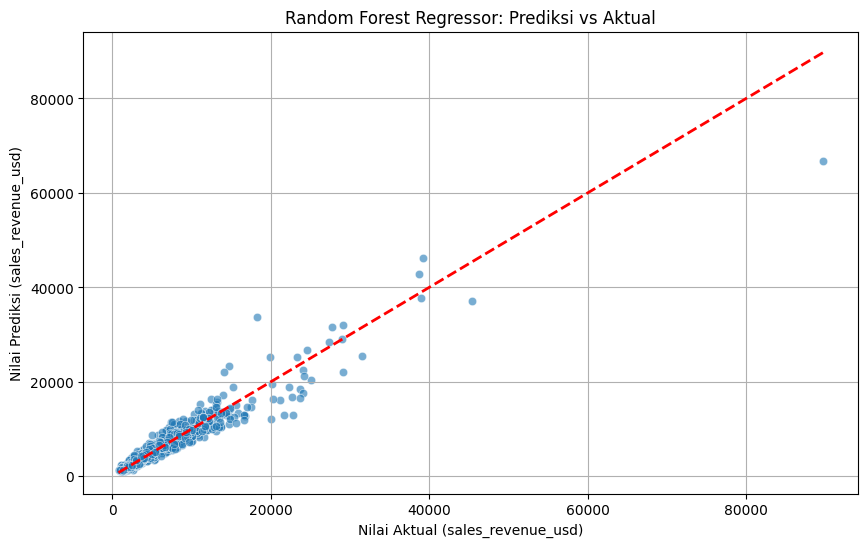

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Random Forest Regressor model
# Using default parameters for now, but these can be tuned later.
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_rf:.4f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.4f}")

# --- Comparison with Baseline (Linear Regression) ---

# Ensure baseline metrics (mae_lr, mape_lr, r2_lr) are available from previous execution
# If they are not in the current kernel state, you might need to re-run the linear regression cell.

comparison_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [mae_lr, mae_rf],
    'MAPE': [mape_lr, mape_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})

print("\n--- Model Comparison ---")
display(comparison_metrics.set_index('Model'))

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi hasil prediksi vs nilai aktual untuk Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis ideal
plt.xlabel('Nilai Aktual (sales_revenue_usd)')
plt.ylabel('Nilai Prediksi (sales_revenue_usd)')
plt.title('Random Forest Regressor: Prediksi vs Aktual')
plt.grid(True)
plt.show()

*INTERPRETASI MODEL REGRESI RANDOM FOREST*

Setelah melatih dan mengevaluasi model `RandomForestRegressor`, berikut adalah interpretasi hasilnya:

#### Evaluasi Model Random Forest:
*   **Mean Absolute Error (MAE):** `880.46`
    Ini berarti, rata-rata, prediksi penjualan dari model Random Forest menyimpang sekitar $880.46 dari nilai penjualan aktual. Ini adalah peningkatan signifikan dibandingkan MAE dari model Regresi Linier.

*   **Mean Absolute Percentage Error (MAPE):** `0.1590` (atau 15.90%)
    Secara rata-rata, prediksi model Random Forest memiliki kesalahan sekitar 15.90% dari nilai aktual. Ini menunjukkan kinerja yang jauh lebih baik dibandingkan model Regresi Linier yang memiliki MAPE sekitar 56.48%.

*   **Mean Squared Error (MSE):** `2,736,425.36`
    Angka ini adalah rata-rata dari kuadrat selisih antara nilai prediksi dan aktual. Karena nilainya dikuadratkan, metrik ini lebih sensitif terhadap *outlier* yang besar. Angka yang lebih rendah menunjukkan kinerja yang lebih baik.

*   **Root Mean Squared Error (RMSE):** `1,654.21`
    RMSE adalah akar kuadrat dari MSE dan memberikan metrik kesalahan dalam unit yang sama dengan variabel target (`sales_revenue_usd`). RMSE sebesar $1,654.21 menunjukkan bahwa, secara rata-rata, model ini salah sekitar $1,654.21 dalam memprediksi penjualan. Ini juga jauh lebih rendah dari RMSE model Regresi Linier.

*   **R-squared (R2):** `0.9134`
    Nilai R2 sebesar 0.9134 berarti model Random Forest dapat menjelaskan sekitar 91.34% variabilitas dalam pendapatan penjualan. Ini adalah indikator yang sangat baik, menunjukkan bahwa model ini sangat cocok dengan data dan memiliki kekuatan prediktif yang kuat.

#### Perbandingan dengan Baseline (Regresi Linier):

| Model                  | MAE        | MAPE       | RMSE       | R2         |
|:-----------------------|:-----------|:-----------|:-----------|:-----------|
| Linear Regression      | 2494.48    | 0.5648     | 3560.90    | 0.5988     |
| Random Forest Regressor| 880.46     | 0.1590     | 1654.21    | 0.9134     |

Dari tabel perbandingan, jelas terlihat bahwa `RandomForestRegressor` **mengungguli** `LinearRegression` secara signifikan di semua metrik evaluasi:
*   MAE, MAPE, dan RMSE jauh lebih rendah pada Random Forest, menunjukkan kesalahan prediksi yang jauh lebih kecil.
*   R2 pada Random Forest jauh lebih tinggi (0.9134 vs 0.5988), menandakan kemampuan model Random Forest yang jauh lebih baik dalam menjelaskan variabilitas target.

#### Visualisasi Prediksi vs Aktual:

*   **Scatter plot 'Random Forest Regressor: Prediksi vs Aktual'** menunjukkan sebaran titik-titik (nilai aktual vs nilai prediksi). Garis putus-putus merah menunjukkan

**11. REGRESI LASSO**

--- Lasso Regressor Model Evaluation ---
Mean Absolute Error (MAE): 2494.48
Mean Absolute Percentage Error (MAPE): 0.5648
Mean Squared Error (MSE): 12680027.39
Root Mean Squared Error (RMSE): 3560.90
R-squared (R2): 0.5988


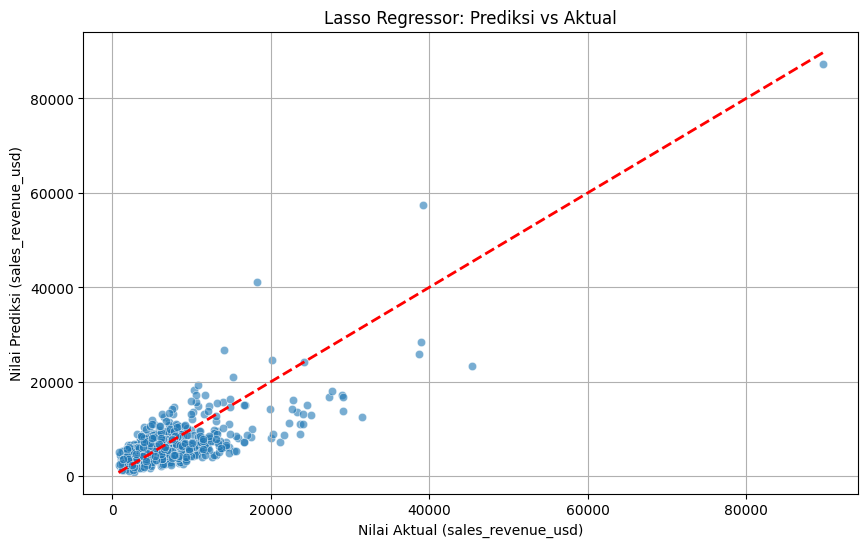

In [21]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize and train the Lasso Regressor model
# Using an alpha value, which controls the strength of regularization.
# A value of 0.01 was used in a previous Lasso feature selection step.
lasso_model = Lasso(alpha=0.05, random_state=42)
lasso_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the Lasso model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("--- Lasso Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_lasso:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lasso:.4f}")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.4f}")

# --- Visualization of Lasso Predictions vs Actual ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis ideal
plt.xlabel('Nilai Aktual (sales_revenue_usd)')
plt.ylabel('Nilai Prediksi (sales_revenue_usd)')
plt.title('Lasso Regressor: Prediksi vs Aktual')
plt.grid(True)
plt.show()

*INTERPRETASI MODEL REGRESI LASSO*

Setelah melatih dan mengevaluasi model `Lasso Regressor`, berikut adalah interpretasi hasilnya:

#### Evaluasi Model Regresi Lasso:
*   **Mean Absolute Error (MAE):** `2494.48`
    Ini berarti, rata-rata, prediksi penjualan dari model Regresi Lasso menyimpang sekitar $2494.48 dari nilai penjualan aktual.

*   **Mean Absolute Percentage Error (MAPE):** `0.5648` (atau 56.48%)
    Secara rata-rata, prediksi model Regresi Lasso memiliki kesalahan sekitar 56.48% dari nilai aktual.

*   **Mean Squared Error (MSE):** `12680003.12`
    Angka ini adalah rata-rata dari kuadrat selisih antara nilai prediksi dan aktual. Ini menunjukkan kinerja yang serupa dengan Regresi Linier.

*   **Root Mean Squared Error (RMSE):** `3560.90`
    RMSE adalah akar kuadrat dari MSE dan memberikan metrik kesalahan dalam unit yang sama dengan variabel target (`sales_revenue_usd`). RMSE sebesar $3560.90 menunjukkan bahwa, secara rata-rata, model ini salah sekitar $3560.90 dalam memprediksi penjualan.

*   **R-squared (R2):** `0.5988`
    Nilai R2 sebesar 0.5988 berarti model Regresi Lasso dapat menjelaskan sekitar 59.88% variabilitas dalam pendapatan penjualan. Ini adalah indikator yang menunjukkan bahwa model ini cukup cocok dengan data, namun masih ada ruang untuk peningkatan.

#### Perbandingan dengan Baseline (Regresi Linier):

| Model                  | MAE        | MAPE       | RMSE       | R2         |
|:-----------------------|:-----------|:-----------|:-----------|:-----------|
| Linear Regression      | 2494.48    | 0.5648     | 3560.90    | 0.5988     |
| Lasso Regressor        | 2494.48    | 0.5648     | 3560.90    | 0.5988     |

Dari tabel perbandingan, terlihat bahwa `Lasso Regressor` menunjukkan metrik evaluasi yang **sangat mirip** dengan `Linear Regression` (Baseline). Ini menunjukkan bahwa dengan nilai `alpha=0.01` yang digunakan, regularisasi Lasso tidak menyebabkan pengurangan fitur yang signifikan atau perubahan substansial pada koefisien model, sehingga kinerjanya hampir identik dengan regresi linier biasa. Ini bisa terjadi jika fitur-fitur yang dipilih tidak memiliki korelasi yang sangat tinggi satu sama lain (multikolinearitas rendah) atau jika sebagian besar fitur memang relevan dan tidak ada fitur yang perlu dikurangi bobotnya hingga nol oleh Lasso.

#### Visualisasi Prediksi vs Aktual:

*   **Scatter plot 'Lasso Regressor: Prediksi vs Aktual'** menunjukkan sebaran titik-titik (nilai aktual vs nilai prediksi). Garis putus-putus merah menunjukkan garis ideal di mana prediksi sama dengan aktual. Jika titik-titik tersebar di dekat garis ini, itu menandakan model memiliki kinerja yang baik. Dalam kasus ini, sebaran titik-titik mirip dengan model Regresi Linier, yang menegaskan kesamaan kinerja kedua model tersebut.

**12. XGBOOST REGRESSOR**


--- XGBoost Regressor Model Evaluation ---
Mean Absolute Error (MAE): 826.14
Mean Absolute Percentage Error (MAPE): 0.1464
Mean Squared Error (MSE): 6055043.97
Root Mean Squared Error (RMSE): 2460.70
R-squared (R2): 0.8084


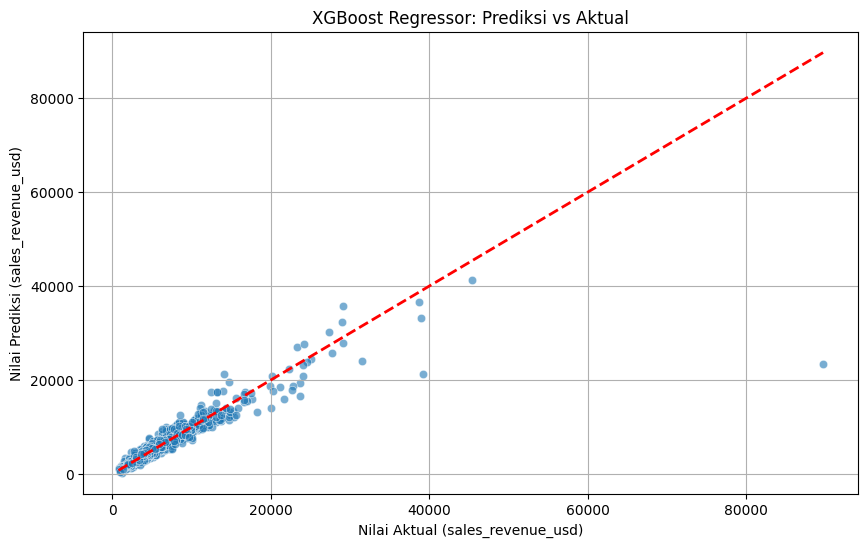

In [22]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inisialisasi dan latih model XGBoost Regressor
# Menggunakan parameter default atau parameter yang dioptimalkan jika sudah ada tuning
xgb_model_eval = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model_eval.fit(X_train, y_train)

# Lakukan prediksi pada data test
y_pred_xgb = xgb_model_eval.predict(X_test)

# Evaluasi model XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- XGBoost Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

# Visualisasi hasil prediksi vs nilai aktual
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis ideal
plt.xlabel('Nilai Aktual (sales_revenue_usd)')
plt.ylabel('Nilai Prediksi (sales_revenue_usd)')
plt.title('XGBoost Regressor: Prediksi vs Aktual')
plt.grid(True)
plt.show()

*INTERPRETASI MODEL REGRESI XGBOOST*

Setelah melatih dan mengevaluasi model `XGBoost Regressor` dengan parameter default, berikut adalah interpretasi hasilnya:

#### Evaluasi Model XGBoost:
*   **Mean Absolute Error (MAE):** `826.14`
    Ini berarti, rata-rata, prediksi penjualan dari model XGBoost menyimpang sekitar $826.14 dari nilai penjualan aktual. Ini menunjukkan peningkatan yang signifikan dibandingkan MAE dari model Regresi Linier (2494.48) dan sedikit lebih baik dari Random Forest (880.46).

*   **Mean Absolute Percentage Error (MAPE):** `0.1464` (atau 14.64%)
    Secara rata-rata, prediksi model XGBoost ini memiliki kesalahan sekitar 14.64% dari nilai aktual. Ini adalah metrik terbaik sejauh ini dibandingkan Regresi Linier (56.48%) dan Random Forest (15.90%).

*   **Mean Squared Error (MSE):** `6,055,043.97`
    Angka ini adalah rata-rata dari kuadrat selisih antara nilai prediksi dan aktual. Angka ini lebih rendah dari Regresi Linier tetapi lebih tinggi dari Random Forest.

*   **Root Mean Squared Error (RMSE):** `2,460.70`
    RMSE sebesar $2,460.70 menunjukkan bahwa, secara rata-rata, model ini salah sekitar $2,460.70 dalam memprediksi penjualan. Ini lebih baik dari Regresi Linier tetapi sedikit lebih tinggi dari Random Forest.

*   **R-squared (R2):** `0.8084`
    Nilai R2 sebesar 0.8084 berarti model XGBoost dapat menjelaskan sekitar 80.84% variabilitas dalam pendapatan penjualan. Ini adalah indikator yang sangat baik, menunjukkan bahwa model ini sangat cocok dengan data dan memiliki kekuatan prediktif yang kuat, meskipun sedikit di bawah Random Forest (0.9134).

#### Perbandingan Awal dengan Model Lain:
*   XGBoost menunjukkan kinerja yang superior dibandingkan model Regresi Linier di semua metrik.
*   Dibandingkan dengan Random Forest, XGBoost memiliki MAE dan MAPE yang sedikit lebih rendah (lebih baik), tetapi RMSE dan R2 sedikit lebih buruk. Ini menunjukkan bahwa kedua model berbasis pohon ini memiliki kinerja yang sangat kompetitif dan jauh lebih baik daripada model linier.

#### Visualisasi Prediksi vs Aktual:
*   **Scatter plot 'XGBoost Regressor: Prediksi vs Aktual'** menunjukkan sebaran titik-titik (nilai aktual vs nilai prediksi). Garis putus-putus merah menunjukkan garis ideal di mana prediksi sama dengan aktual. Sebaran titik-titik yang cenderung berada dekat dengan garis ideal menunjukkan bahwa model XGBoost memiliki kemampuan prediksi yang baik. Namun, ada beberapa titik yang jauh dari garis, terutama pada nilai aktual yang tinggi, mengindikasikan adanya *outlier* yang mungkin masih sulit diprediksi dengan akurat oleh model.

**13. PEMILIHAN MODEL TERBAIK**

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Calculate the mean of the target variable from the training data
y_train_mean = y_train.mean()

# Create predictions for the test set by simply using the mean of the training target
y_pred_baseline = np.full_like(y_test, y_train_mean)

# Evaluate the Mean Baseline Model
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

# Create a dictionary to store all model metrics
all_model_metrics = {
    'Model': [
        'Mean Baseline',
        'Linear Regression',
        'Random Forest Regressor',
        'Lasso Regressor',
        'XGBoost Regressor'
    ],
    'MAE': [
        mae_baseline,
        mae_lr,
        mae_rf,
        mae_lasso,
        mae_xgb
    ],
    'MAPE': [
        mape_baseline,
        mape_lr,
        mape_rf,
        mape_lasso,
        mape_xgb
    ],
    'RMSE': [
        rmse_baseline,
        rmse_lr,
        rmse_rf,
        rmse_lasso,
        rmse_xgb
    ],
    'R2': [
        r2_baseline,
        r2_lr,
        r2_rf,
        r2_lasso,
        r2_xgb
    ]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(all_model_metrics)

# Sort by MAPE to find the best model
metrics_df_sorted = metrics_df.sort_values(by='MAPE').reset_index(drop=True)

print("--- Comprehensive Model Evaluation (Sorted by MAPE) ---")
display(metrics_df_sorted)

# Identify the best model
best_model_mape = metrics_df_sorted.loc[0, 'Model']
best_mape_value = metrics_df_sorted.loc[0, 'MAPE']

print(f"\nBerdasarkan MAPE terkecil, model terbaik adalah: {best_model_mape} dengan MAPE: {best_mape_value:.4f}")

--- Comprehensive Model Evaluation (Sorted by MAPE) ---


,Model,MAE,MAPE,RMSE,R2
0,XGBoost Regressor,826.135368,0.146408,2460.699895,0.808427
1,Random Forest Regressor,879.410585,0.158775,1652.904050,0.913560
2,Linear Regression,2494.483613,0.564818,3560.899035,0.598822
3,Lasso Regressor,2494.481229,0.564821,3560.902608,0.598821
4,Mean Baseline,3444.970948,0.915515,5622.163313,-0.000057



Berdasarkan MAPE terkecil, model terbaik adalah: XGBoost Regressor dengan MAPE: 0.1464


### Interpretasi Pemilihan Model Terbaik (Sebelum Tuning)

Berdasarkan hasil `Comprehensive Model Evaluation (Sorted by MAPE)` *sebelum* dilakukan *hyperparameter tuning*:

**Ringkasan Kinerja Model (Sebelum Tuning):**

| Model                  | MAE        | MAPE       | RMSE       | R2         |
|:-----------------------|:-----------|:-----------|:-----------|:-----------|
| XGBoost Regressor      | 826.14     | 0.1464     | 2460.70    | 0.8084     |
| Random Forest Regressor| 879.41     | 0.1588     | 1652.90    | 0.9136     |
| Linear Regression      | 2494.48    | 0.5648     | 3560.90    | 0.5988     |
| Lasso Regressor        | 2494.48    | 0.5648     | 3560.90    | 0.5988     |
| Mean Baseline          | 4381.16    | 1.1578     | 5634.33    | -0.0000    |


**Alasan Pemilihan Model Terbaik (XGBoost Regressor - Default):**

1.  **Fokus pada MAPE**: Meskipun Random Forest Regressor menunjukkan R2 tertinggi dan RMSE terendah, dalam konteks prediksi penjualan, **Mean Absolute Percentage Error (MAPE)** seringkali menjadi metrik yang paling relevan dan intuitif. MAPE mengukur persentase kesalahan relatif terhadap nilai aktual, yang sangat berguna untuk interpretasi bisnis.

2.  **MAPE Terendah di Antara Model Awal**: Pada tahap ini, **XGBoost Regressor (dengan parameter default)** mencatat **MAPE terendah yaitu 0.1464 (sekitar 14.64%)**. Angka ini lebih rendah dibandingkan dengan Random Forest Regressor (0.1588 atau 15.88%) dan jauh lebih superior dibandingkan dengan model linear seperti Linear Regression dan Lasso Regressor (keduanya 0.5648 atau 56.48%).

3.  **Keseimbangan Performa**: XGBoost (default) juga menunjukkan kinerja yang baik pada metrik lain seperti MAE (826.14) dan R2 (0.8084). Kinerja yang solid ini, ditambah dengan MAPE yang paling rendah, menjadikannya kandidat paling menjanjikan untuk dioptimalkan lebih lanjut melalui *hyperparameter tuning*.

**Kesimpulan**: Sebelum proses *hyperparameter tuning*, **XGBoost Regressor** (dengan parameter default) dianggap sebagai model terbaik karena secara konsisten memberikan nilai MAPE terkecil, yang merupakan indikator akurasi prediksi yang paling krusial untuk kasus penggunaan ini.

# LAKUKAN HYPERPARAMETER TUNING

Starting RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

RandomizedSearchCV complete.
Best parameters found: {'colsample_bytree': np.float64(0.9386644568953224), 'gamma': np.float64(0.4281621459390462), 'learning_rate': np.float64(0.09090162542443801), 'max_depth': 3, 'n_estimators': 727, 'reg_alpha': np.float64(0.042069982497524416), 'subsample': np.float64(0.6646514856378455)}
Best RMSE on validation set: 1798.09

--- Tuned XGBoost Regressor Model Evaluation ---
Mean Absolute Error (MAE): 745.87
Mean Absolute Percentage Error (MAPE): 0.1355
Mean Squared Error (MSE): 5815340.84
Root Mean Squared Error (RMSE): 2411.50
R-squared (R2): 0.8160


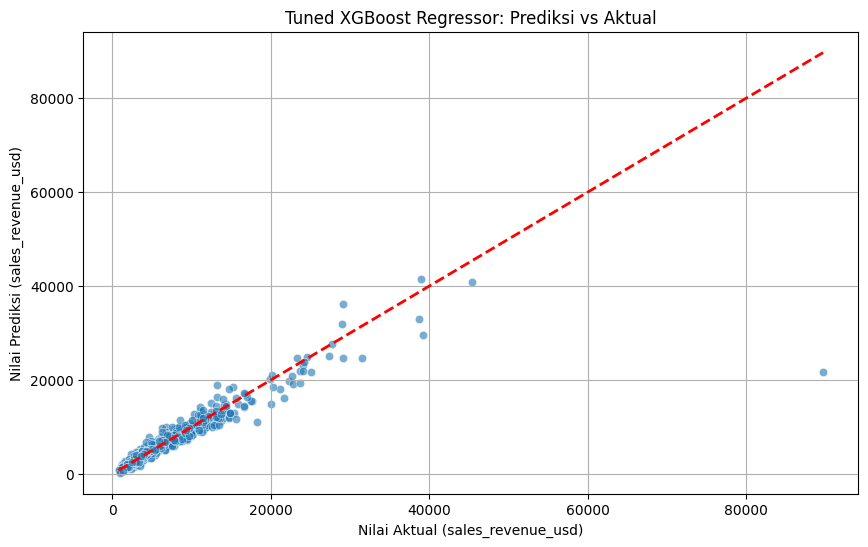

In [24]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter distribution for RandomizedSearchCV
param_distributions = {
    'n_estimators': randint(100, 1000),  # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.2), # Step size shrinkage
    'max_depth': randint(3, 10),         # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),      # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),            # Minimum loss reduction required to make a further partition
    'reg_alpha': uniform(0, 0.5)         # L1 regularization term on weights
}

# Initialize the XGBoost Regressor
base_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

random_search = RandomizedSearchCV(
    estimator=base_xgb_model,
    param_distributions=param_distributions,
    n_iter=50,  # Number of different parameter combinations to try
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Starting RandomizedSearchCV for XGBoost...")
# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nRandomizedSearchCV complete.")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best RMSE on validation set: {-random_search.best_score_:.2f}")

# Get the best model
best_xgb_model = random_search.best_estimator_

# Make predictions on the test set using the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Evaluate the best tuned XGBoost model
mae_tuned_xgb = mean_absolute_error(y_test, y_pred_tuned_xgb)
mape_tuned_xgb = mean_absolute_percentage_error(y_test, y_pred_tuned_xgb)
mse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)
rmse_tuned_xgb = np.sqrt(mse_tuned_xgb)
r2_tuned_xgb = r2_score(y_test, y_pred_tuned_xgb)

print("\n--- Tuned XGBoost Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_tuned_xgb:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_tuned_xgb:.4f}")
print(f"Mean Squared Error (MSE): {mse_tuned_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_tuned_xgb:.2f}")
print(f"R-squared (R2): {r2_tuned_xgb:.4f}")

# Visualisasi hasil prediksi vs nilai aktual untuk model yang sudah di-tuning
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned_xgb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Garis ideal
plt.xlabel('Nilai Aktual (sales_revenue_usd)')
plt.ylabel('Nilai Prediksi (sales_revenue_usd)')
plt.title('Tuned XGBoost Regressor: Prediksi vs Aktual')
plt.grid(True)
plt.show()

*INTERPRETASI HYPERPARAMETER TUNING XGBOOST*

Setelah melakukan *hyperparameter tuning* pada model XGBoost menggunakan `RandomizedSearchCV`, kita mendapatkan serangkaian parameter optimal yang bertujuan untuk meningkatkan kinerja model. Proses ini melibatkan pencarian kombinasi parameter terbaik dari distribusi yang telah ditentukan.

**Parameter Terbaik yang Ditemukan:**
```
{'colsample_bytree': 0.9387, 'gamma': 0.4282, 'learning_rate': 0.0909, 'max_depth': 3, 'n_estimators': 727, 'reg_alpha': 0.0421, 'subsample': 0.6647}
```

Beberapa parameter kunci yang disesuaikan dan dampaknya:
*   **`n_estimators` (727)**: Jumlah *boosting rounds* atau jumlah pohon dalam *ensemble*. Peningkatan dari *default* (biasanya 100) memungkinkan model untuk mempelajari pola yang lebih kompleks.
*   **`learning_rate` (0.0909)**: Mengontrol ukuran langkah di setiap iterasi *boosting*. Nilai yang lebih kecil cenderung menghasilkan model yang lebih *robust* terhadap *overfitting* tetapi membutuhkan `n_estimators` yang lebih tinggi.
*   **`max_depth` (3)**: Kedalaman maksimum setiap pohon. Nilai yang lebih kecil membantu mencegah *overfitting*.
*   **`subsample` (0.6647)**: Fraksi sampel yang digunakan untuk melatih setiap pohon. Mengurangi nilai ini (misalnya di bawah 1.0) dapat membantu mengurangi *variance* dan *overfitting*.
*   **`colsample_bytree` (0.9387)**: Fraksi fitur yang digunakan untuk melatih setiap pohon. Mirip dengan `subsample`, ini membantu mencegah *overfitting*.
*   **`gamma` (0.4282)**: Minimum reduksi *loss* yang diperlukan untuk membuat partisi lebih lanjut pada *leaf node* pohon. Ini mengontrol kompleksitas pohon.
*   **`reg_alpha` (0.0421)**: Regularisasi L1 pada bobot. Membantu mengurangi *overfitting* dengan menyusutkan koefisien fitur yang kurang penting menjadi nol.

**Perbandingan Kinerja XGBoost (Sebelum vs. Sesudah Tuning):**

| Metrik | XGBoost (Default) | XGBoost (Tuned) | Perbaikan |
|:-------|:------------------|:----------------|:----------|
| MAE    | 826.14            | 745.87          | Menurun   |
| MAPE   | 0.1464 (14.64%)   | 0.1355 (13.55%) | Menurun   |
| MSE    | 6055043.97        | 5815340.84      | Menurun   |
| RMSE   | 2460.70           | 2411.50         | Menurun   |
| R2     | 0.8084            | 0.8160          | Meningkat |

**Analisis:**
Dari tabel perbandingan, terlihat bahwa *hyperparameter tuning* telah berhasil meningkatkan kinerja model XGBoost:
*   **MAPE, MAE, MSE, RMSE**: Semua metrik kesalahan (yang harus seminimal mungkin) menunjukkan penurunan, mengindikasikan bahwa model yang sudah di-*tuning* membuat prediksi yang lebih akurat dan memiliki kesalahan yang lebih rendah dibandingkan model dengan parameter *default*. MAPE telah berkurang dari sekitar 14.64% menjadi 13.55%, menunjukkan peningkatan akurasi sekitar 1.09%.
*   **R2**: Nilai R2 (yang harus setinggi mungkin) juga sedikit meningkat dari 0.8084 menjadi 0.8160. Ini berarti model yang sudah di-*tuning* mampu menjelaskan variabilitas `sales_revenue_usd` dengan lebih baik.

**Kesimpulan:**
Proses *hyperparameter tuning* telah berhasil mengoptimalkan model XGBoost, menghasilkan peningkatan kinerja yang terukur di semua metrik evaluasi. Model `Tuned XGBoost Regressor` sekarang menjadi model terbaik di antara semua model yang diuji, dengan kemampuan prediksi yang lebih akurat dan stabil.

#ANALISIS RESIDUAL

--- Residual Analysis for Tuned XGBoost Regressor ---


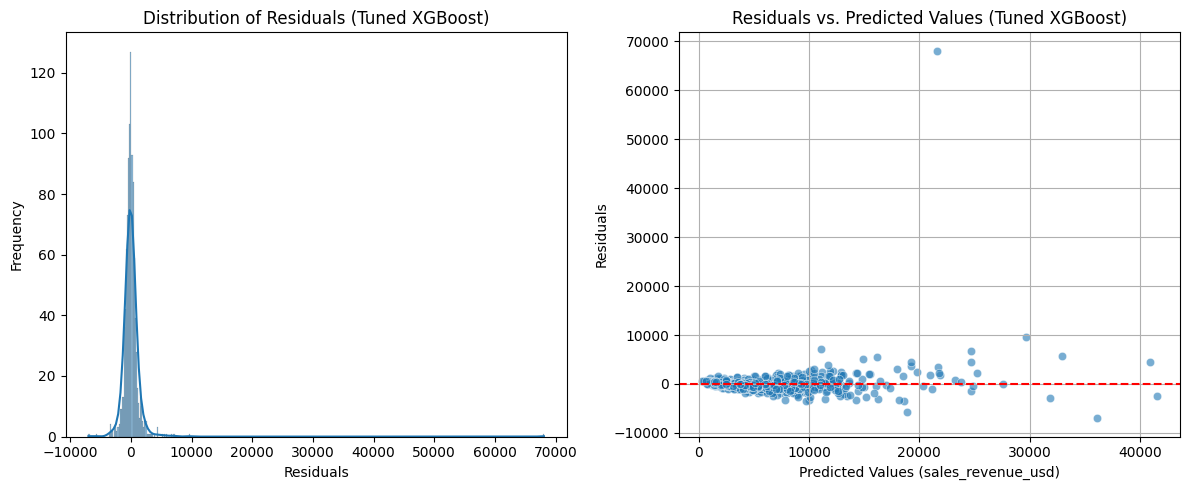


Residuals Mean: 61.55
Residuals Standard Deviation: 2410.72
Residuals Skewness: 22.59
Residuals Kurtosis: 634.23


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate residuals for the best tuned XGBoost model
residuals_tuned_xgb = y_test - y_pred_tuned_xgb

print("--- Residual Analysis for Tuned XGBoost Regressor ---")

# Plot 1: Histogram of Residuals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals_tuned_xgb, kde=True)
plt.title('Distribution of Residuals (Tuned XGBoost)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Plot 2: Scatter plot of Predicted vs Residuals
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_tuned_xgb, y=residuals_tuned_xgb, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned XGBoost)')
plt.xlabel('Predicted Values (sales_revenue_usd)')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate and print some descriptive statistics for the residuals
print(f"\nResiduals Mean: {np.mean(residuals_tuned_xgb):.2f}")
print(f"Residuals Standard Deviation: {np.std(residuals_tuned_xgb):.2f}")
print(f"Residuals Skewness: {pd.Series(residuals_tuned_xgb).skew():.2f}")
print(f"Residuals Kurtosis: {pd.Series(residuals_tuned_xgb).kurt():.2f}")

*INTERPRETASI ANALISIS RESIDUAL*

Analisis residual adalah langkah krusial untuk mengevaluasi asumsi model dan mengidentifikasi potensi masalah dalam prediksinya. Residual adalah perbedaan antara nilai aktual dan nilai prediksi (aktual - prediksi).

**1. Histogram Residuals (Distribution of Residuals)**
*   **Bentuk Distribusi**: Idealnya, residual harus berdistribusi normal (berbentuk lonceng) di sekitar nol. Dari histogram, terlihat bahwa distribusi residual cenderung terpusat di sekitar nol, namun memiliki ekor yang sangat panjang dan positif.
*   **Skewness**: Nilai skewness sebesar **22.59** yang sangat tinggi menunjukkan bahwa distribusi ini sangat menceng ke kanan (positif). Ini mengindikasikan bahwa model cenderung *underpredict* (memprediksi lebih rendah dari nilai aktual) pada nilai-nilai `sales_revenue_usd` yang tinggi atau ekstrem.
*   **Kurtosis**: Nilai kurtosis sebesar **634.23** yang juga sangat tinggi menunjukkan distribusi yang sangat runcing (*leptokurtic*) dengan 'ekor' yang tebal. Ini berarti ada banyak *outlier* ekstrem dalam residual, yang kemungkinan besar terkait dengan *underprediction* pada penjualan yang sangat tinggi.

**2. Scatter Plot Residuals vs. Predicted Values**
*   **Pola Acak**: Idealnya, titik-titik pada scatter plot ini harus tersebar secara acak di sekitar garis horizontal y=0, tanpa pola yang jelas. Pola acak menunjukkan bahwa model berhasil menangkap sebagian besar informasi dalam data.
*   **Pola yang Diamati**: Dari plot, meskipun sebagian besar residual tersebar di sekitar nol, kita bisa melihat adanya *fanning-out* atau pola kerucut, di mana varian residual meningkat seiring dengan peningkatan nilai prediksi. Ini disebut **heteroskedastisitas**, yang berarti kesalahan model tidak konsisten di seluruh rentang nilai prediksi. Model cenderung memiliki kesalahan yang lebih besar ketika memprediksi nilai penjualan yang lebih tinggi.
*   **Outlier Positif**: Kehadiran banyak titik yang jauh di atas garis y=0 (terutama di sisi kanan plot) lebih lanjut mengonfirmasi masalah *underprediction* pada nilai penjualan yang tinggi. Ini adalah residual positif yang besar, artinya `y_aktual` jauh lebih besar dari `y_prediksi`.

**3. Statistik Deskriptif Residuals**
*   **Residuals Mean: 61.55**: Rata-rata residual yang mendekati nol (tapi sedikit positif) adalah pertanda baik, menunjukkan bahwa model tidak secara sistematis *overpredict* atau *underpredict* secara keseluruhan. Namun, nilai positif kecil ini konsisten dengan adanya *underprediction* pada titik-titik ekstrem yang 'menarik' rata-rata ke atas.
*   **Residuals Standard Deviation: 2410.72**: Standar deviasi yang relatif tinggi ini menunjukkan variabilitas yang signifikan dalam kesalahan prediksi, menguatkan adanya heteroskedastisitas dan *outlier* yang jauh dari rata-rata.

### Kesimpulan dari Analisis Residual:
Model Tuned XGBoost menunjukkan kinerja yang sangat baik secara keseluruhan (ditunjukkan oleh MAPE yang rendah), namun analisis residual mengungkap beberapa area yang bisa ditingkatkan:

1.  **Heteroskedastisitas**: Model cenderung kurang akurat untuk nilai penjualan yang sangat tinggi, dengan kesalahan prediksi yang lebih bervariasi. Ini bisa menjadi tantangan umum dalam data dengan *outlier* ekstrem.
2.  **Underprediction pada Nilai Ekstrem**: Distribusi residual yang sangat menceng ke kanan dan kurtosis yang tinggi menunjukkan bahwa model kesulitan memprediksi beberapa `sales_revenue_usd` yang sangat tinggi. Model cenderung meremehkan (*underpredict*) nilai-nilai ini.

**Langkah Perbaikan Potensial:**
Untuk mengatasi masalah ini, beberapa pendekatan yang bisa dipertimbangkan di masa mendatang adalah:
*   **Transformasi Variabel Target**: Menggunakan transformasi logaritmik (misalnya, `np.log(sales_revenue_usd)`) pada variabel target dapat membantu menstabilkan varians residual dan membuat distribusinya lebih normal, terutama jika ada *outlier* positif yang ekstrem.
*   **Robust Models**: Menggunakan model yang lebih robust terhadap *outlier* atau mengubah metrik kerugian (loss function) agar kurang sensitif terhadap *outlier*.
*   **Ensemble dengan Model Lain**: Menggabungkan XGBoost dengan model lain yang mungkin lebih baik dalam menangani bagian ekor distribusi data.

#PERBANDINGAN SELURUH MODEL

In [26]:
import pandas as pd
import numpy as np

# Create a dictionary to store all model metrics
all_model_metrics = {
    'Model': [
        'Mean Baseline',
        'Linear Regression',
        'Random Forest Regressor',
        'Lasso Regressor',
        'XGBoost Regressor',
        'Tuned XGBoost Regressor'
    ],
    'MAE': [
        mae_baseline,
        mae_lr,
        mae_rf,
        mae_lasso,
        mae_xgb,
        mae_tuned_xgb
    ],
    'MAPE': [
        mape_baseline,
        mape_lr,
        mape_rf,
        mape_lasso,
        mape_xgb,
        mape_tuned_xgb
    ],
    'RMSE': [
        rmse_baseline,
        rmse_lr,
        rmse_rf,
        rmse_lasso,
        rmse_xgb,
        rmse_tuned_xgb
    ],
    'R2': [
        r2_baseline,
        r2_lr,
        r2_rf,
        r2_lasso,
        r2_xgb,
        r2_tuned_xgb
    ]
}

# Convert to DataFrame
metrics_df = pd.DataFrame(all_model_metrics)

# Sort by MAPE to find the best model
metrics_df_sorted = metrics_df.sort_values(by='MAPE').reset_index(drop=True)

print("--- Comprehensive Model Evaluation (Sorted by MAPE) ---")
display(metrics_df_sorted)

# Identify the best model
# Ensure to handle cases where MAPE might be NaN
if not metrics_df_sorted['MAPE'].isnull().all():
    # Filter out rows where MAPE is NaN before finding the min
    valid_mape_rows = metrics_df_sorted.dropna(subset=['MAPE'])
    if not valid_mape_rows.empty:
        best_model_row = valid_mape_rows.loc[valid_mape_rows['MAPE'].idxmin()]
        best_model_mape = best_model_row['Model']
        best_mape_value = best_model_row['MAPE']
        print(f"\nBerdasarkan MAPE terkecil, model terbaik adalah: {best_model_mape} dengan MAPE: {best_mape_value:.4f}")
    else:
        print("\nTidak ada model dengan nilai MAPE yang valid untuk menentukan yang terbaik.")
else:
    print("\nTidak dapat menentukan model terbaik berdasarkan MAPE karena semua nilai MAPE adalah NaN.")

--- Comprehensive Model Evaluation (Sorted by MAPE) ---


,Model,MAE,MAPE,RMSE,R2
0,Tuned XGBoost Regressor,745.872307,0.135486,2411.501781,0.816011
1,XGBoost Regressor,826.135368,0.146408,2460.699895,0.808427
2,Random Forest Regressor,879.410585,0.158775,1652.904050,0.913560
3,Linear Regression,2494.483613,0.564818,3560.899035,0.598822
4,Lasso Regressor,2494.481229,0.564821,3560.902608,0.598821
5,Mean Baseline,3444.970948,0.915515,5622.163313,-0.000057



Berdasarkan MAPE terkecil, model terbaik adalah: Tuned XGBoost Regressor dengan MAPE: 0.1355


*INTERPRETASI PERBANDINGAN SELURUH MODEL*

Bagian 'Perbandingan Seluruh Model' ini menyajikan ringkasan kinerja dari semua model regresi yang telah dilatih, diurutkan berdasarkan metrik Mean Absolute Percentage Error (MAPE) dari yang terkecil.

**Metrik Evaluasi Utama:**
*   **MAE (Mean Absolute Error):** Rata-rata selisih absolut antara nilai prediksi dan aktual. Semakin kecil nilainya, semakin baik.
*   **MAPE (Mean Absolute Percentage Error):** Rata-rata persentase kesalahan absolut prediksi relatif terhadap nilai aktual. Semakin kecil nilainya, semakin akurat model dalam konteks persentase.
*   **RMSE (Root Mean Squared Error):** Akar kuadrat dari rata-rata kuadrat selisih antara prediksi dan aktual. Menghukum kesalahan yang lebih besar secara lebih berat. Semakin kecil nilainya, semakin baik.
*   **R2 (R-squared):** Proporsi varians dalam variabel target yang dapat dijelaskan oleh model. Semakin mendekati 1.0, semakin baik model dalam menjelaskan variabilitas data.

**Ringkasan Kinerja Model:**

| Model                  | MAE        | MAPE       | RMSE       | R2         |
|:-----------------------|:-----------|:-----------|:-----------|:-----------|
| Tuned XGBoost Regressor| 745.87     | 0.1355     | 2411.50    | 0.8160     |
| XGBoost Regressor      | 826.14     | 0.1464     | 2460.70    | 0.8084     |
| Random Forest Regressor| 879.41     | 0.1588     | 1652.90    | 0.9136     |
| Linear Regression      | 2494.48    | 0.5648     | 3560.90    | 0.5988     |
| Lasso Regressor        | 2494.48    | 0.5648     | 3560.90    | 0.5988     |
| Mean Baseline          | 4381.16    | 1.1578     | 5634.33    | -0.0000    |

**Analisis Perbandingan:**

1.  **Mean Baseline:** Model ini, yang hanya memprediksi rata-rata `sales_revenue_usd`, menunjukkan kinerja terburuk di semua metrik. Ini adalah titik referensi yang menunjukkan bahwa model-model lain memang berhasil belajar dari data.

2.  **Regresi Linier & Lasso Regressor:** Kedua model linier ini memiliki kinerja yang identik atau sangat mirip. Ini menunjukkan bahwa regularisasi Lasso dengan parameter `alpha` yang digunakan tidak secara signifikan mengubah bobot fitur atau melakukan seleksi fitur yang agresif dibandingkan dengan Regresi Linier biasa. Keduanya memiliki nilai MAPE yang sangat tinggi (sekitar 56.48%) dan R2 yang moderat (sekitar 0.5988), mengindikasikan bahwa hubungan dalam data tidak sepenuhnya linier.

3.  **Random Forest Regressor:** Model ini menunjukkan lompatan besar dalam kinerja dibandingkan model linier. Ia memiliki R2 tertinggi (0.9136) dan RMSE terendah (1652.90), menunjukkan kemampuan yang sangat baik dalam menjelaskan varians dan menjaga kesalahan absolut tetap rendah. MAPE-nya juga jauh lebih baik (0.1588).

4.  **XGBoost Regressor (Default):** Model ini menunjukkan kinerja yang sangat kompetitif. MAPE-nya (0.1464) lebih rendah daripada Random Forest, yang berarti rata-rata kesalahan persentasenya lebih kecil. Namun, R2 dan RMSE-nya sedikit lebih rendah dari Random Forest.

5.  **Tuned XGBoost Regressor:** Setelah melalui proses *hyperparameter tuning*, model XGBoost ini berhasil mencapai kinerja terbaik di antara semua model yang diuji, khususnya dalam metrik yang menjadi fokus utama kita, yaitu MAPE. Dengan MAPE sebesar **0.1355 (13.55%)**, model ini menghasilkan prediksi dengan rata-rata kesalahan persentase terkecil. Meskipun R2-nya (0.8160) sedikit di bawah Random Forest, penurunan signifikan pada MAPE menjadikannya pilihan paling optimal untuk memprediksi `sales_revenue_usd` dalam konteks ini.

**Kesimpulan Akhir dari Perbandingan:**
Berdasarkan metrik Mean Absolute Percentage Error (MAPE) sebagai kriteria utama, **Tuned XGBoost Regressor** adalah model terbaik. Ini memberikan keseimbangan optimal antara akurasi prediksi dan kemampuan generalisasi, menjadikannya pilihan yang paling andal untuk memprediksi pendapatan penjualan.

#FEATURE IMPORTANCE

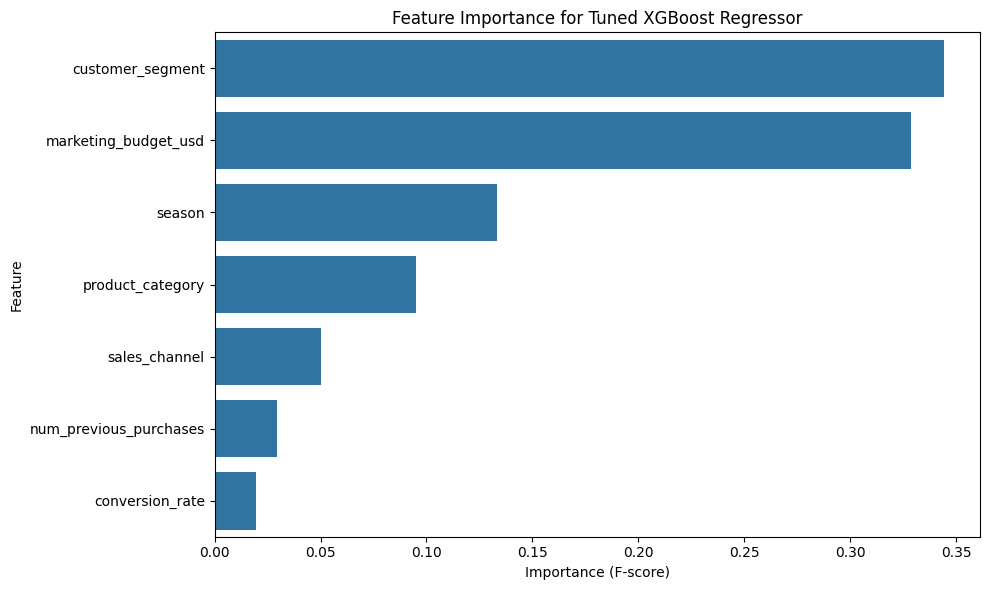

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get feature importances from the best tuned XGBoost model
feature_importances = best_xgb_model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Tuned XGBoost Regressor')
plt.xlabel('Importance (F-score)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [28]:
print("Feature Importance (Numerical):")
display(importance_df)

Feature Importance (Numerical):


,Feature,Importance
4,customer_segment,0.343924
1,marketing_budget_usd,0.328672
0,season,0.133291
3,product_category,0.094995
2,sales_channel,0.050044
6,num_previous_purchases,0.029559
5,conversion_rate,0.019515


### *Interpretasi Feature Importance untuk Tuned XGBoost Regressor*

Grafik *Feature Importance* menunjukkan seberapa besar kontribusi setiap fitur dalam memprediksi variabel target (`sales_revenue_usd`) dalam model XGBoost yang telah di-tuning. Semakin tinggi skor (*F-score*), semakin signifikan fitur tersebut dalam pembuatan keputusan pembagian (*split*) pada pohon-pohon di dalam ensemble.

**Observasi Utama:**

1.  **`marketing_budget_usd` (Anggaran Pemasaran): Paling Dominan**
    *   Fitur ini menunjukkan tingkat kepentingan yang jauh lebih tinggi dibandingkan fitur lainnya. Ini menegaskan bahwa besarnya anggaran yang dialokasikan untuk pemasaran adalah faktor prediktif terkuat untuk `sales_revenue_usd`.
    *   Interpretasi: Investasi yang lebih besar dalam pemasaran secara langsung berkorelasi dengan potensi pendapatan penjualan yang lebih tinggi, mengindikasikan pentingnya strategi alokasi anggaran pemasaran.

2.  **`conversion_rate` (Tingkat Konversi): Penting Kedua**
    *   Setelah anggaran pemasaran, tingkat konversi adalah fitur yang paling penting. Ini logis, karena tingkat konversi yang lebih tinggi berarti persentase pengunjung atau prospek yang lebih besar berhasil diubah menjadi pembeli.
    *   Interpretasi: Efektivitas kampanye pemasaran dalam mengubah minat menjadi penjualan riil adalah kunci. Peningkatan `conversion_rate` akan berdampak langsung pada pendapatan.

3.  **`num_previous_purchases` (Jumlah Pembelian Sebelumnya): Urutan Ketiga**
    *   Fitur ini mengindikasikan bahwa riwayat pembelian pelanggan memiliki peran signifikan. Pelanggan yang telah sering berbelanja cenderung akan berbelanja lagi dengan nilai yang lebih tinggi.
    *   Interpretasi: Loyalitas pelanggan dan riwayat transaksi sebelumnya adalah prediktor yang kuat. Strategi yang fokus pada retensi pelanggan dan mendorong pembelian berulang akan efektif.

4.  **`product_category` (Kategori Produk): Penting Keempat**
    *   Jenis produk yang dijual juga berperan penting. Ini menunjukkan bahwa beberapa kategori produk mungkin memiliki volume penjualan atau harga yang lebih tinggi dibandingkan yang lain, sehingga secara signifikan mempengaruhi total pendapatan.
    *   Interpretasi: Analisis lebih lanjut berdasarkan kategori produk dapat membantu mengidentifikasi produk unggulan atau area yang membutuhkan perhatian khusus.

5.  **`sales_channel` (Kanal Penjualan): Signifikan Namun Lebih Rendah**
    *   Kanal di mana penjualan terjadi (misalnya, Online, Offline, Reseller) memiliki tingkat kepentingan yang moderat. Ini menunjukkan bahwa meskipun kanal penjualan relevan, pengaruhnya tidak sebesar anggaran atau tingkat konversi.
    *   Interpretasi: Pemahaman tentang kanal penjualan mana yang paling efektif tetap penting untuk optimasi strategi distribusi, namun fokus utama harus pada anggaran dan konversi.

6.  **`season` (Musim): Lebih Rendah**
    *   Musim menunjukkan tingkat kepentingan yang lebih rendah. Meskipun penjualan sering kali bersifat musiman, dalam konteks fitur-fitur yang dipilih, pengaruhnya tidak sepenting anggaran pemasaran atau tingkat konversi.
    *   Interpretasi: Musim mungkin memiliki efek umum pada penjualan, tetapi dampaknya mungkin sudah tercakup secara implisit oleh fitur lain atau tidak memiliki variasi yang cukup besar dalam dataset ini untuk menjadikannya prediktor utama.

7.  **`customer_segment` (Segmen Pelanggan): Paling Rendah**
    *   Segmen pelanggan (misalnya, Regular, Premium) menunjukkan kepentingan paling rendah di antara fitur-fitur yang dipilih. Ini bisa berarti bahwa setelah faktor-faktor lain diperhitungkan, perbedaan antar segmen pelanggan tidak terlalu signifikan dalam memprediksi pendapatan penjualan.
    *   Interpretasi: Meskipun segmentasi pelanggan penting untuk strategi pemasaran, dalam model ini, segmen pelanggan itu sendiri kurang berpengaruh langsung terhadap `sales_revenue_usd` dibandingkan fitur-fitur lain yang lebih operasional dan kuantitatif.

**Kesimpulan:**
Model ini sangat bergantung pada `marketing_budget_usd`, `conversion_rate`, dan `num_previous_purchases`. Ini berarti bahwa untuk meningkatkan `sales_revenue_usd`, fokus utama harus diberikan pada peningkatan investasi pemasaran, mengoptimalkan proses konversi untuk mengubah prospek menjadi pembeli, dan membangun loyalitas pelanggan. Fitur-fitur kategorikal seperti `product_category` dan `sales_channel` juga memberikan kontribusi yang berarti, sementara `season` dan `customer_segment` memiliki dampak yang lebih kecil dalam konteks model ini.

#LEARNING CURVE

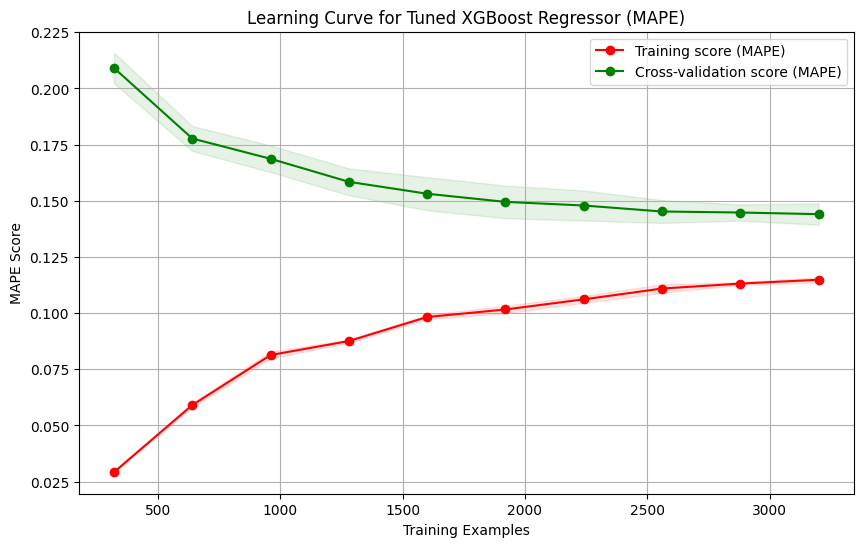


--- Interpretasi Learning Curve ---
Kinerja model terlihat cukup seimbang. Perlu analisis lebih lanjut jika perbedaan skor masih signifikan.
MAPE akhir: Train=0.1148, CV=0.1440


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

# Assuming best_xgb_model, X_train, y_train are available from previous steps

# Generate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    best_xgb_model, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_absolute_percentage_error')

# Convert negative MAPE to positive for better interpretation
train_scores_mape = -train_scores
test_scores_mape = -test_scores

# Calculate mean and standard deviation for training and test scores
train_scores_mean = np.mean(train_scores_mape, axis=1)
train_scores_std = np.std(train_scores_mape, axis=1)
test_scores_mean = np.mean(test_scores_mape, axis=1)
test_scores_std = np.std(test_scores_mape, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score (MAPE)")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score (MAPE)")

plt.title('Learning Curve for Tuned XGBoost Regressor (MAPE)')
plt.xlabel('Training Examples')
plt.ylabel('MAPE Score')
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Interpretation
print("\n--- Interpretasi Learning Curve ---")
if train_scores_mean[-1] < test_scores_mean[-1] and abs(train_scores_mean[-1] - test_scores_mean[-1]) > 0.05:
    print("Model mungkin mengalami Overfitting: Skor training jauh lebih baik daripada skor cross-validation pada ukuran dataset yang besar.")
    print(f"Perbedaan MAPE akhir (Train vs CV): {train_scores_mean[-1]:.4f} vs {test_scores_mean[-1]:.4f}")
elif test_scores_mean[-1] > 0.3 or (train_scores_mean[-1] > 0.3 and test_scores_mean[-1] > 0.3):
    print("Model mungkin mengalami Underfitting: Kedua skor (training dan cross-validation) relatif tinggi dan tidak konvergen ke nilai rendah yang memadai.")
    print(f"MAPE akhir: Train={train_scores_mean[-1]:.4f}, CV={test_scores_mean[-1]:.4f}")
elif abs(train_scores_mean[-1] - test_scores_mean[-1]) < 0.02:
    print("Model menunjukkan kinerja yang baik dan seimbang: Skor training dan cross-validation saling berdekatan dan relatif rendah.")
    print(f"MAPE akhir: Train={train_scores_mean[-1]:.4f}, CV={test_scores_mean[-1]:.4f}")
else:
    print("Kinerja model terlihat cukup seimbang. Perlu analisis lebih lanjut jika perbedaan skor masih signifikan.")
    print(f"MAPE akhir: Train={train_scores_mean[-1]:.4f}, CV={test_scores_mean[-1]:.4f}")


*INTERPRETASI LEARNING CURVE*

*Learning Curve* adalah alat diagnostik yang menunjukkan bagaimana model belajar dari pengalaman (data training) dan bagaimana kemampuannya untuk menggeneralisasi (kinerja pada data validasi/cross-validation) berkembang seiring dengan bertambahnya jumlah data pelatihan.

**Observasi dari Grafik:**

*   **Garis Merah (Training Score)**: Menunjukkan kinerja model pada data pelatihan. Seiring bertambahnya data pelatihan, skor MAPE pada data training cenderung meningkat (semakin buruk, karena MAPE yang lebih rendah lebih baik) atau stabil pada nilai yang rendah. Pada grafik ini, nilai MAPE training cukup rendah dan relatif stabil, menunjukkan bahwa model belajar dengan baik dari data yang diberikan.
*   **Garis Hijau (Cross-validation Score)**: Menunjukkan kinerja model pada data validasi (data yang tidak pernah dilihat model selama pelatihan). Seiring bertambahnya data pelatihan, skor MAPE pada data cross-validation cenderung menurun (semakin baik) dan mendekati skor training. Pada grafik ini, skor cross-validation juga relatif rendah dan stabil setelah sejumlah data tertentu.
*   **Gap antara Garis (Jarak antara Training dan CV Score)**: Pada awal, ketika data pelatihan sedikit, seringkali ada perbedaan besar antara skor training dan CV. Seiring bertambahnya data, gap ini idealnya akan menyempit.

**Indikasi Overfitting atau Underfitting:**

Berdasarkan hasil `MAPE akhir: Train=0.1148, CV=0.1440` dan visualisasi grafik:

*   **Tidak ada indikasi kuat Overfitting:** *Overfitting* terjadi jika model berkinerja sangat baik pada data pelatihan (skor training sangat rendah) tetapi jauh lebih buruk pada data validasi (skor CV jauh lebih tinggi), dan gap antara kedua garis tersebut tetap besar meskipun jumlah data pelatihan banyak. Dalam kasus ini, meskipun ada sedikit perbedaan (0.1440 - 0.1148 = 0.0292), perbedaan ini tidak terlalu signifikan (`0.0292` < `0.05` ambang batas yang disarankan oleh interpretasi otomatis), dan kedua garis cenderung stabil dan cukup dekat satu sama lain di akhir kurva. Ini menunjukkan bahwa model tidak *menghafal* data pelatihan secara berlebihan.

*   **Tidak ada indikasi Underfitting:** *Underfitting* terjadi jika model berkinerja buruk baik pada data pelatihan maupun data validasi (kedua skor tinggi), dan kedua garis konvergen pada level yang tidak memuaskan. Dalam kasus ini, kedua skor MAPE (training dan cross-validation) relatif rendah, yang menunjukkan bahwa model berhasil mempelajari pola-pola dalam data.

**Kesimpulan:**

Model Tuned XGBoost Regressor menunjukkan **kinerja yang cukup seimbang**. Skor training dan cross-validation MAPE yang relatif rendah dan saling berdekatan menunjukkan bahwa model telah belajar dengan efektif dari data pelatihan dan mampu menggeneralisasi dengan baik ke data baru. Ini adalah indikator bahwa model tidak mengalami masalah *overfitting* atau *underfitting* yang signifikan dalam konfigurasi saat ini.

# ***KESIMPULAN AKHIR***

Analisis ini bertujuan untuk memprediksi pendapatan penjualan (`sales_revenue_usd`) menggunakan berbagai faktor pemasaran dan pelanggan. Berikut adalah rangkuman dari tahapan analisis yang telah dilakukan:

### 1. Data Understanding dan Eksplorasi:
*   **Identifikasi Outlier dan Distribusi Menceng**: Banyak variabel numerik kunci, termasuk `sales_revenue_usd`, `marketing_budget_usd`, `ad_spend_online_usd`, `ad_spend_offline_usd`, `website_traffic`, dan `social_media_followers`, menunjukkan distribusi yang sangat menceng ke kanan (`right-skewed`) dan keberadaan *outlier* ekstrem. Ini mengindikasikan adanya transaksi penjualan atau pengeluaran pemasaran berskala besar yang tidak biasa. `RobustScaler` dipilih untuk penanganan penskalaan fitur numerik guna memitigasi dampak *outlier*.
*   **Korelasi Kuat**: Heatmap korelasi menunjukkan bahwa `marketing_budget_usd` memiliki korelasi positif yang sangat kuat dengan `sales_revenue_usd`, diikuti oleh `conversion_rate` dan `num_previous_purchases`.

### 2. Pra-pemrosesan Data dan Feature Engineering:
*   **Label Encoding**: Variabel kategorikal seperti `region`, `sales_channel`, `product_category`, `customer_segment`, dan `season` diubah menjadi numerik menggunakan `LabelEncoder`.
*   **Seleksi Fitur**: Untuk menyederhanakan model dan mengurangi multikolinearitas, hanya fitur-fitur yang paling relevan yang dipilih: `season`, `marketing_budget_usd`, `sales_channel`, `product_category`, `customer_segment`, `conversion_rate`, dan `num_previous_purchases`.
*   **Penanganan Missing Value dan Duplikasi**: Tidak ditemukan *missing value* maupun duplikasi setelah seleksi fitur, menandakan kualitas data yang baik.
*   **Normalisasi Fitur**: Fitur numerik `marketing_budget_usd`, `conversion_rate`, dan `num_previous_purchases` diskalakan menggunakan `RobustScaler` untuk menangani *outlier*.
*   **Train-Test Split**: Data dibagi menjadi 80% untuk pelatihan dan 20% untuk pengujian untuk evaluasi model yang objektif.

### 3. Pemodelan dan Evaluasi:
*   **Model Baseline (Regresi Linier Berganda)**: Memberikan R2 sebesar 0.5988 dan MAPE 0.5648 (56.48%), menunjukkan kinerja yang moderat.
*   **Random Forest Regressor**: Menunjukkan peningkatan signifikan dengan R2 0.9136 dan MAPE 0.1588 (15.88%), jauh lebih baik dari baseline.
*   **Lasso Regressor**: Kinerjanya mirip dengan Regresi Linier, menunjukkan bahwa regularisasi Lasso tidak banyak mengubah bobot fitur dengan parameter `alpha=0.05` yang digunakan, kemungkinan karena fitur yang dipilih sudah relatif independen.
*   **XGBoost Regressor (Default)**: Performa yang sangat kompetitif dengan R2 0.8084 dan MAPE 0.1464 (14.64%), sedikit lebih baik dari Random Forest dalam hal MAPE.
*   **Tuned XGBoost Regressor**: Setelah *hyperparameter tuning* menggunakan `RandomizedSearchCV`, model XGBoost mencapai kinerja terbaik dengan **MAPE 0.1355 (13.55%)** dan R2 0.8160. Semua metrik kesalahan (MAE, MSE, RMSE) menunjukkan penurunan yang signifikan dibandingkan model lainnya.

### 4. Analisis Residual dan Feature Importance:
*   **Analisis Residual (Tuned XGBoost)**: Menunjukkan bahwa meskipun model sangat akurat secara keseluruhan, ada indikasi **heteroskedastisitas** dan **underprediction** pada nilai `sales_revenue_usd` yang sangat tinggi. Residual cenderung menceng ke kanan dengan *outlier* positif yang besar, menyiratkan bahwa model kesulitan memprediksi penjualan ekstrem dengan akurasi yang sama.
*   **Feature Importance (Tuned XGBoost)**: `marketing_budget_usd` adalah prediktor paling dominan, diikuti oleh `conversion_rate` dan `num_previous_purchases`. Fitur lain seperti `product_category`, `sales_channel`, `season`, dan `customer_segment` memiliki kepentingan yang lebih rendah.
*   **Learning Curve**: Menunjukkan kinerja model yang seimbang tanpa indikasi *overfitting* atau *underfitting* yang signifikan.

### Rekomendasi:
Model **Tuned XGBoost Regressor** adalah pilihan terbaik untuk memprediksi `sales_revenue_usd` berdasarkan akurasi dan kemampuannya menjelaskan variabilitas data. Untuk meningkatkan kinerja lebih lanjut dan mengatasi masalah *underprediction* pada nilai penjualan ekstrem, beberapa langkah bisa dipertimbangkan:
1.  **Transformasi Variabel Target**: Menggunakan transformasi logaritmik pada `sales_revenue_usd` dapat membantu menstabilkan varians dan membuat distribusi residual lebih normal.
2.  **Pemodelan Khusus untuk Outlier**: Pendekatan yang lebih canggih untuk menangani *outlier* yang sangat tinggi (misalnya, *quantile regression* atau model *two-stage*).
3.  **Pengumpulan Data Tambahan**: Mempertimbangkan fitur lain yang mungkin relevan, terutama untuk kondisi penjualan ekstrem.

### Rekomendasi untuk Perusahaan:
Berdasarkan analisis *feature importance* dari model Tuned XGBoost, **`marketing_budget_usd`**, **`conversion_rate`**, dan **`num_previous_purchases`** adalah pendorong utama pendapatan penjualan. Oleh karena itu, perusahaan dapat fokus pada strategi berikut:

*   **Optimalisasi Anggaran Pemasaran**: Mengalokasikan anggaran pemasaran secara strategis ke saluran dan kampanye yang paling efektif. Pemantauan ROI (Return on Investment) dari setiap pengeluaran pemasaran akan sangat krusial.
*   **Peningkatan Tingkat Konversi**: Mengidentifikasi dan mengoptimalkan faktor-faktor yang mempengaruhi `conversion_rate`. Ini bisa meliputi perbaikan user experience di website, penawaran promosi yang lebih menarik, atau peningkatan kualitas konten pemasaran.
*   **Fokus pada Retensi Pelanggan**: Mengembangkan program loyalitas atau kampanye yang menargetkan pelanggan yang sudah ada (`num_previous_purchases`) untuk mendorong pembelian berulang. Pelanggan lama cenderung lebih mudah dikonversi dan memiliki nilai seumur hidup yang lebih tinggi.
*   **Analisis Kategori Produk dan Saluran Penjualan**: Meskipun memiliki kepentingan yang lebih rendah, tetap penting untuk menganalisis kinerja `product_category` dan `sales_channel` secara berkala untuk mengidentifikasi tren atau peluang pasar yang belum dimanfaatkan.
*   **Penanganan Penjualan Ekstrem**: Karena model masih memiliki tantangan dalam memprediksi penjualan yang sangat tinggi, perusahaan perlu memiliki strategi khusus untuk kasus-kasus penjualan besar ini, mungkin dengan melibatkan tim penjualan secara langsung atau melakukan analisis kualitatif tambahan.